# Data Visualisation Coursework Template

- These headings are only a recommended structure.
- The wordcount code only works in Jupyter Notebook! You can still use JupyterLab to produce your report if you wish but you will need to use Jupyter Notebook to check the number of words.
- Please delete this text!

# Patterns and Contexts of Reported Road Collisions in Great Britain: A Visual Investigation of STATS19 Data

## Note - This notebook is for *notes and the analysis and visualisation code* **ONLY**. The .pdf Report is the ultimate deliverable, so refer to it for full explanation and proper formatting!

## 1. Introduction

* Road collisions remain an important transport and public-safety issue in Great Britain.
* Long-term casualty numbers have generally fallen, but recent changes are smaller and patterns differ by severity and road environment (Department for Transport, 2025a).
* Rural and urban roads show different profiles:
    * most casualties occur in urban areas
    * a larger share of fatalities occurs on rural roads
    * suggests collision frequency and severity do not necessarily follow the same pattern.
* Previous research shows severity is linked with several road and environmental factors.
* Higher posted speed limits have been associated with greater odds of severe/fatal injury in British collision data (Mason-Jones et al., 2022).
* Street design, road-network structure and traffic characteristics can also influence casualty severity (Sarkar et al., 2018).
* This study uses STATS19 collision data, 2021–2025, for Great Britain.
* Focus of analysis:
    * change over time
    * road characteristics
    * environmental conditions
    * temporal patterns
    * geographic concentration

* Main aim:
    * compare collision frequency and severity patterns
    * identify where they align or differ
    * keep interpretation descriptive rather than causal or exposure-adjusted.

## Research  topic

The Research objective if this study is - **To use visual analysis of STATS19 collision records to examine how the frequency and severity of reported road collisions in Great Britain vary over time, across road and environmental contexts, and geographically.** The analysis and discussion of this work is **aimed at** *Road-safety policymakers, local transport authorities and transport planners.*

The study focuses on variation in reported road-collision frequency and severity across Great Britain. Rather than treating all collisions as a single group, the investigation considers how outcomes differ according to road environment, environmental conditions, time and location. The primary objective is to identify patterns that may be useful for road-safety monitoring and planning while recognising that observational collision data cannot by itself establish why those patterns occur.

The analysis is structured around five research questions covering overall temporal change, road characteristics, environmental conditions, shorter-term temporal patterns and geographic concentration. These dimensions were selected because they can all be examined within the same STATS19 collision dataset and provide complementary views of the road-safety problem.

* RQ1 - How have the number and severity of reported road collisions in Great Britain changed over the five-year study period?
* RQ2 - How does collision severity vary across different road environments, including speed limit, road type and urban or rural location?
* RQ3 - How does collision severity vary under different lighting, weather and road-surface conditions?
* RQ4 - What temporal patterns are visible in serious and fatal collisions by hour of day, day of week and month?
* RQ5 - Where are serious and fatal collisions geographically concentrated, and how does their spatial distribution compare with reported collisions overall?


## Code setup
These libraries are used throughout the project and are pre-requisite for running the entire workflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 

import seaborn as sns
import geopandas as gpd

# for country outline download
import requests
from pathlib import Path

## 2. Data collection

The analysis uses the Department for Transport STATS19 collision dataset covering the most recent five-year period available in the downloaded file. STATS19 records personal-injury road collisions reported to the police in Great Britain and provides one observation for each reported collision. The selected collision file was used as a single source rather than combining the separate casualty and vehicle files, as it already contains the variables required for the research questions.

**Data source** - https://www.gov.uk/government/statistical-data-sets/road-safety-open-data -> Road Safety Data - Collisions - last 5 years (CSV, 97.7MB)

i.e. https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-last-5-years.csv

## 3. Data overview

The raw dataset contains 513,801 collision records and 44 variables. Each row represents one reported collision. The available fields include collision severity, date and time, number of vehicles and casualties, speed limit, road type, junction characteristics, lighting, weather and road-surface conditions, urban/rural classification and geographic coordinates. 

Initial inspection showed that collision_index and collision_ref_no contain mixed representations and are identifiers rather than quantities. so they were imported as strings to preserve their values consistently and avoid numerical code interpretation.

* no fully duplicated rows. 
* Standard pandas missing-value checks showed only 53 records with missing geographic coordinates, although STATS19 also uses coded values for unknown or unreported categories. These coded values therefore require separate inspection before the analytical dataset is finalised.

In [2]:
# import identifiers as strings so they aren't treated as numbers
roads_raw = pd.read_csv(
    "data/dft-road-casualty-statistics-collision-last-5-years.csv",
    dtype={
        "collision_index": "string",
        "collision_ref_no": "string"
    }
) 

print("rows:", roads_raw.shape[0])
print("columns:", roads_raw.shape[1])
print("duplicate rows:", roads_raw.duplicated().sum())

rows: 513801
columns: 44
duplicate rows: 0


In [3]:
display(roads_raw.head(3))

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0.0,1.0


In [4]:
print(roads_raw.dtypes)

collision_index                                     string[python]
collision_year                                               int64
collision_ref_no                                    string[python]
location_easting_osgr                                      float64
location_northing_osgr                                     float64
longitude                                                  float64
latitude                                                   float64
police_force                                                 int64
collision_severity                                           int64
number_of_vehicles                                           int64
number_of_casualties                                         int64
date                                                        object
day_of_week                                                  int64
time                                                        object
local_authority_district                                     i

### Relevant variables 
These have been identified as the variables most relevant to the 5 research questions:

| Variable                  | Type                | Role in analysis                     | Relevant RQ(s)   |
| ------------------------- | ------------------- | ------------------------------------ | ---------------- |
| `collision_severity`      | Ordinal categorical | Main outcome: slight, serious, fatal | RQ1–RQ5          |
| `date`                    | Temporal            | Annual, monthly and weekday patterns | RQ1, RQ4         |
| `time`                    | Temporal            | Hour-of-day patterns                 | RQ4              |
| `collision_year`          | Temporal/discrete   | Five-year trend comparison           | RQ1              |
| `speed_limit`             | Numerical/discrete  | Road-environment comparison          | RQ2              |
| `road_type`               | Nominal categorical | Road-environment comparison          | RQ2              |
| `urban_or_rural_area`     | Nominal categorical | Urban/rural comparison               | RQ2              |
| `light_conditions`        | Nominal categorical | Environmental context                | RQ3              |
| `weather_conditions`      | Nominal categorical | Environmental context                | RQ3              |
| `road_surface_conditions` | Nominal categorical | Environmental context                | RQ3              |
| `number_of_vehicles`      | Numerical/count     | Descriptive collision characteristic | Supporting       |
| `number_of_casualties`    | Numerical/count     | Collision-impact context             | Supporting       |
| `longitude`               | Spatial/numerical   | Geographic positioning               | RQ5              |
| `latitude`                | Spatial/numerical   | Geographic positioning               | RQ5              |


In [5]:

missing = (roads_raw
           .isna()
           .sum()
           .sort_values(ascending=False)
           .rename("missing")
           .to_frame()
)
missing["missing_pct"] = missing["missing"] / len(roads_raw) * 100

display(missing.head(10))

,missing,missing_pct
location_easting_osgr,53,0.010315
location_northing_osgr,53,0.010315
longitude,53,0.010315
latitude,53,0.010315
collision_index,0,0.000000
carriageway_hazards_historic,0,0.000000
second_road_number,0,0.000000
pedestrian_crossing_human_control_historic,0,0.000000
pedestrian_crossing_physical_facilities_historic,0,0.000000
pedestrian_crossing,0,0.000000


In [6]:
# initial severity summary

severity_summary = (roads_raw["collision_severity"]
    .value_counts()
    .rename_axis("severity")
    .to_frame("collisions")
)

severity_summary["percentage"] = (severity_summary["collisions"] /severity_summary["collisions"].sum() * 100)
display(severity_summary.round(2))

,collisions,percentage
severity,,
3,389435,75.79
2,116813,22.74
1,7553,1.47


In [7]:
# initial statistics 
display(roads_raw[["number_of_vehicles", "number_of_casualties", "speed_limit"]].describe().round(2))

,number_of_vehicles,number_of_casualties,speed_limit
count,513801.00,513801.00,513801.00
mean,1.82,1.27,35.90
std,0.69,0.73,14.37
min,1.00,1.00,-1.00
25%,1.00,1.00,30.00
50%,2.00,1.00,30.00
75%,2.00,1.00,40.00
max,26.00,142.00,70.00


## 4. Pre-processing

### 4.1. Pruning

Since not all 44 columns are of interest for the 5 research questions, only the 16 key variables identifier earlier are retained.

In [8]:
# keep only variables needed for the research questions
keep_cols = [
    "collision_index",
    "collision_ref_no",
    "collision_year",
    "date",
    "time",
    "collision_severity",
    "number_of_vehicles",
    "number_of_casualties",
    "speed_limit",
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "longitude",
    "latitude"
]
# do not alter original dataframe
roads_pruned = roads_raw[keep_cols].copy()

### 4.2. Typing

In [9]:
# check dtypes and cardinality to decide how to type columns
dtype_table = pd.DataFrame({"dtype": roads_pruned.dtypes.astype(str),"unique_values": roads_pruned.nunique(dropna=False)})
display(dtype_table)

,dtype,unique_values
collision_index,string,513801
collision_ref_no,string,510837
collision_year,int64,5
date,object,1826
time,object,1440
collision_severity,int64,3
number_of_vehicles,int64,19
number_of_casualties,int64,26
speed_limit,int64,7
road_type,int64,6


#### 2.1 Nominal categories

In [10]:
# copy dt for traceability and access to raw data for comparisons
roads_typed = roads_pruned.copy()

# type nominal columns
nominal_cols = [
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
]

for col in nominal_cols:
    roads_typed[col] = roads_typed[col].astype("category")

Although Speed limit can be considered categorical Nominal, there is a meaningful difference in values so it is left as numeric for ranking purposes rather than

#### 2.2 Ordinal categories
The dataset spans the transition from the 2011 to 2024 STATS19 specification. Most variables used in this analysis retained comparable definitions, but **road-surface recording changed** because oil/diesel and mud were moved to a new carriageway-hazards variable. This was considered when interpreting road-surface patterns. The data guide from https://www.gov.uk/government/statistical-data-sets/road-safety-open-data notes changes during this transition.


| Variable| 2024 transition issue?| What changed / what it means|
| ---| ---|--- |
| `collision_severity`      | None | |
| `road_type`               | No category change in the current coding ||
| `urban_or_rural_area`     | No transition issue| |
| `light_conditions`        | No transition issue | |
| `weather_conditions`      | No transition issue| |
| `road_surface_conditions` | **YES**| Codes for **Oil or diesel** (6) and **Mud** (7) were moved into the new combined `conditions_and_carriageway_hazards`|

however the below check shows 6 and 7 never appear in the dataset which suggests the data has already been harmonised with the current format.


In [11]:
cat_cols = [
    "collision_severity",
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

# check raw codes for unexpected values before mapping
for col in cat_cols:
    print(f"\n{col}")
    print(roads_typed[col].value_counts(dropna=False).sort_index())


collision_severity
collision_severity
1      7553
2    116813
3    389435
Name: count, dtype: int64

road_type
road_type
1     31178
2     11550
3     76119
6    373065
7      8829
9     13060
Name: count, dtype: int64

urban_or_rural_area
urban_or_rural_area
-1         8
 1    345314
 2    168429
 3        50
Name: count, dtype: int64

light_conditions
light_conditions
-1        34
 1    368193
 4    105834
 5      3706
 6     27438
 7      8596
Name: count, dtype: int64

weather_conditions
weather_conditions
-1        12
 1    413632
 2     55834
 3      1791
 4      4472
 5      5173
 6       238
 7      2128
 8     15955
 9     14566
Name: count, dtype: int64

road_surface_conditions
road_surface_conditions
-1      3527
 1    374268
 2    120572
 3      1257
 4      6668
 5       788
 9      6721
Name: count, dtype: int64


##### 2.2.1 Road Surface Conditions
road_surface_conditions

In [12]:
print(roads_typed["road_surface_conditions"].dtype)
print(roads_typed["road_surface_conditions"]
    .value_counts(dropna=False)
    .sort_index()
)

int64
road_surface_conditions
-1      3527
 1    374268
 2    120572
 3      1257
 4      6668
 5       788
 9      6721
Name: count, dtype: int64


In [13]:
# initial code drafted by AI, categories manually checked
# STATS19 codebook mapping — same pattern repeated for the other categorical variables below

surface_map = {
    -1: "No data",
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood over 3 cm deep",
    9: "Unknown"
}

roads_typed["road_surface_conditions"] = (roads_pruned["road_surface_conditions"]
    .map(surface_map)
    .astype("category")
)

print(roads_typed["road_surface_conditions"].value_counts(dropna=False))

road_surface_conditions
Dry                     374268
Wet or damp             120572
Unknown                   6721
Frost or ice              6668
No data                   3527
Snow                      1257
Flood over 3 cm deep       788
Name: count, dtype: int64


##### 2.2.2 Collision severity

In [14]:
severity_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

roads_typed["severity"] = roads_typed["collision_severity"].map(severity_map)
severity_type = pd.CategoricalDtype(categories=["Slight", "Serious", "Fatal"],ordered=True)
roads_typed["severity"] = roads_typed["severity"].astype(severity_type)

##### 2.2.3 Road Type 

In [15]:
road_type_map = {
    1: "Roundabout",
    2: "One way street",
    3: "Dual carriageway",
    6: "Single carriageway",
    7: "Slip road",
    9: "Unknown",
    -1: "No data"
}

roads_typed["road_type"] = roads_pruned["road_type"].map(road_type_map).astype("category")

##### 2.2.4 Urban / Rural area 

In [16]:
urban_rural_map = {
    1: "Urban",
    2: "Rural",
    3: "Unallocated",
    -1: "No data"
}

roads_typed["urban_or_rural_area"] = (roads_typed["urban_or_rural_area"]
    .map(urban_rural_map)
    .astype("category")
)

##### 2.2.5 Light conditions

In [17]:
light_map = {
    1: "Daylight",
    4: "Darkness - lights lit",
    5: "Darkness - lights unlit",
    6: "Darkness - no lighting",
    7: "Darkness - lighting unknown",
    -1: "No data"
}

roads_typed["light_conditions"] = (
    roads_typed["light_conditions"]
    .map(light_map)
    .astype("category")
)

##### 2.2.6 Weather conditions

In [18]:
weather_map = {
    1: "Fine no high winds",
    2: "Raining no high winds",
    3: "Snowing no high winds",
    4: "Fine + high winds",
    5: "Raining + high winds",
    6: "Snowing + high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown",
    -1: "No data"
}

roads_typed["weather_conditions"] = (
    roads_typed["weather_conditions"]
    .map(weather_map)
    .astype("category")
)

#### 2.3 Date-time
Date and time were originally generically typed as object, but more precise typing is needed to enable temporal plots and analysis later.

In [19]:
roads_typed["date"] = pd.to_datetime(
    roads_typed["date"],
    format="%d/%m/%Y",
    errors="coerce" # errors="coerce" turns unparsible dates into NaN
)
print("invalid dates:", roads_typed["date"].isna().sum())
print("date range:", roads_typed["date"].min(), "to", roads_typed["date"].max())

invalid dates: 0
date range: 2021-01-01 00:00:00 to 2025-12-31 00:00:00


In [20]:
# combine dates and time to generate continuous datetime data for temporal plotting

roads_typed["collision_datetime"] = pd.to_datetime(
    roads_typed["date"].dt.strftime("%Y-%m-%d")
    + " "
    + roads_typed["time"].astype("string"),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)
print(
    "invalid date/time combinations:",
    roads_typed["collision_datetime"].isna().sum()
)

invalid date/time combinations: 0


#### 2.3.1 Date-time - Feature creation
This is in preparation for consistent yearly plots later

In [21]:
# derive temporal features for later grouping and plotting

roads_typed["hour"] = roads_typed["collision_datetime"].dt.hour
roads_typed["month_name"] = roads_typed["collision_datetime"].dt.month_name()
roads_typed["day_of_week"] = roads_typed["collision_datetime"].dt.day_name()

day_type = pd.CategoricalDtype(
    categories=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],
    ordered=True
)

roads_typed["day_of_week"] = roads_typed["day_of_week"].astype(day_type)

month_type = pd.CategoricalDtype(
    categories=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ],
    ordered=True
)

roads_typed["month_name"] = roads_typed["month_name"].astype(month_type)


#### 2.4 Type check

In [22]:
dtype_summary = pd.DataFrame({
    "dtype": roads_typed.dtypes.astype(str),
    "unique_values": roads_typed.nunique(dropna=False)
})

display(dtype_summary)

,dtype,unique_values
collision_index,string,513801
collision_ref_no,string,510837
collision_year,int64,5
date,datetime64[ns],1826
time,object,1440
collision_severity,int64,3
number_of_vehicles,int64,19
number_of_casualties,int64,26
speed_limit,int64,7
road_type,category,6


In [23]:
# introduced NaN check

decoded_cols = [
    "severity",
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

for col in decoded_cols:
    print(f"\n{col}")
    print(roads_typed[col].value_counts(dropna=False))


severity
severity
Slight     389435
Serious    116813
Fatal        7553
Name: count, dtype: int64

road_type
road_type
Single carriageway    373065
Dual carriageway       76119
Roundabout             31178
Unknown                13060
One way street         11550
Slip road               8829
Name: count, dtype: int64

urban_or_rural_area
urban_or_rural_area
Urban          345314
Rural          168429
Unallocated        50
No data             8
Name: count, dtype: int64

light_conditions
light_conditions
Daylight                       368193
Darkness - lights lit          105834
Darkness - no lighting          27438
Darkness - lighting unknown      8596
Darkness - lights unlit          3706
No data                            34
Name: count, dtype: int64

weather_conditions
weather_conditions
Fine no high winds       413632
Raining no high winds     55834
Other                     15955
Unknown                   14566
Raining + high winds       5173
Fine + high winds          4472
Fog o

### 4.3. Missing audit
#### 4.3.1 Standard missing data check

In [24]:
missing = pd.DataFrame({
    "missing_n": roads_typed.isna().sum(),
    "missing_pct": roads_typed.isna().mean() * 100
})

display(missing.sort_values("missing_n", ascending=False).round(4))


,missing_n,missing_pct
latitude,53,0.0103
longitude,53,0.0103
collision_index,0,0.0000
light_conditions,0,0.0000
month_name,0,0.0000
hour,0,0.0000
collision_datetime,0,0.0000
severity,0,0.0000
road_surface_conditions,0,0.0000
weather_conditions,0,0.0000


Only 53 rows return missing location information.

#### 4.3.2 Coded missing data check
In many categories '-1' means no-data or missing data, whereas in others a category 'unknown' exists. This looks most substantial in road_type and weather_conditions where the recorded 'unknown' is most substantial at 2.5 % and 2.8 % respectively. Although that is still a small proportion of the overall dataset they are retained as they remained valid collision observations for other research questions. Where a variable was directly analysed, records without interpretable information for that variable were excluded only from the relevant comparison.**No missing value rows are globally dropped**

Date-time conversion did not introduce any new NaNs due to parsing errors.

In [25]:
coded_missing_cols = [
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "road_type"
]

coded_missing = []

for col in coded_missing_cols:
    counts = roads_typed[col].value_counts(dropna=False)
    # STATS19 uses coded values like "Unknown"/"No data" — track these separately from NaNs
    # not every column has a "No data" or "Unknown" category, so default to 0 if missing
    no_data_n = counts["No data"] if "No data" in counts else 0
    unknown_n = counts["Unknown"] if "Unknown" in counts else 0

    coded_missing.append({
        "variable": col,
        "no_data_n": no_data_n,
        "unknown_n": unknown_n
    })

coded_missing = pd.DataFrame(coded_missing)
coded_missing["no_data_pct"] = (coded_missing["no_data_n"] / len(roads_typed) * 100)
coded_missing["unknown_pct"] = (coded_missing["unknown_n"] / len(roads_typed) * 100)
display(coded_missing.round(4))

,variable,no_data_n,unknown_n,no_data_pct,unknown_pct
0,urban_or_rural_area,8,0,0.0016,0.0000
1,light_conditions,34,0,0.0066,0.0000
2,weather_conditions,12,14566,0.0023,2.8349
3,road_surface_conditions,3527,6721,0.6865,1.3081
4,road_type,0,13060,0.0000,2.5418


In [26]:
# missing time data check
print("missing dates:",roads_typed["date"].isna().sum())
print("missing datetimes:",roads_typed["collision_datetime"].isna().sum())
print("missing hours:",roads_typed["hour"].isna().sum())

missing dates: 0
missing datetimes: 0
missing hours: 0


#### 4.3.3. Numeric sense check
Sense checking numeric variables does not reveal any immediately suspicious entries. The min-max ad mean values of the below variables seem plausible with perhaps the exception of speed_limit = -1 . This however is explained by the encoding described above which states -1 is used to signify 'No data'.

In [27]:
display(
    roads_typed[
        [
            "number_of_vehicles",
            "number_of_casualties",
            "speed_limit",
            "longitude",
            "latitude"
        ]
    ]
    .describe().round(2)
)

print("collisions < 1 vehicle:",(roads_typed["number_of_vehicles"] < 1).sum())
print("collisions < 1 casualty:",(roads_typed["number_of_casualties"] < 1).sum())

,number_of_vehicles,number_of_casualties,speed_limit,longitude,latitude
count,513801.00,513801.00,513801.00,513748.00,513748.00
mean,1.82,1.27,35.90,-1.21,52.37
std,0.69,0.73,14.37,1.36,1.31
min,1.00,1.00,-1.00,-7.49,49.91
25%,1.00,1.00,30.00,-2.11,51.46
50%,2.00,1.00,30.00,-1.11,51.84
75%,2.00,1.00,40.00,-0.13,53.33
max,26.00,142.00,70.00,1.76,60.50


collisions < 1 vehicle: 0
collisions < 1 casualty: 0


### 4.4. Pre-process Summary
Preprocessing focused on restructuring rather than removing observations. The dataset was reduced from 44 to 16 variables required for the research questions, identifiers were converted to strings, categorical codes were decoded and typed appropriately, and date/time fields were converted and used to derive temporal variables. No rows were removed during these global preprocessing steps. Records coded as Unknown or No data were retained because they remained valid for other analyses; exclusions were instead applied only within the relevant research question. This preserved the maximum available information while avoiding the use of uninterpretable values in specific comparisons.

#### 4.4.1 Transformations
Transformations were performed at various previous steps , this sections serves as a summary and reference for write-up.

| Step                         | Transformation                                                                                                                                  | Purpose                                                                               |
| --- | --- | --- |
| Variable selection| reduced dataset from 44 to 16 variables relevant to the research questions| |
| Identifier typing | Converted `collision_index` and `collision_ref_no` to string| prevents identifier values from interpreting as numeric|
| Category decoding | replaced STATS19 numeric codes with labels for severity, road type, 
urban/rural area, lighting, weather and road-surface conditions | |
| Categorical typing| converted nominal variables to pandas `category`; collision severity was defined as an ordered category| for easy grouping and consistent plot order|
| Date conversion| Converted `date` from `DD/MM/YYYY` text to `datetime64`| for temporal filtering and aggregation|
| Datetime creation| Combined `date` and `time` into `collision_datetime`| for hour-level and other analysis|
| feature engineering - time | Derived `hour`, `day_of_week` and `month_name` | for RQ4 temporal comparisons|
| Time ordering| defined weekdays and months as ordered categorical variables| so plots follow chronological not alphabetical order|
| Missing-value treatment|  `No data` and `Unknown` records retained in the main dataset, with exclusions applied only to analyses requiring those variables| avoids unnecessary global removing of valid records|


#### 4.2 Row-loss summary

No processing step so far has removed any row. Although Research Questions specific NaN reductions will follow and be documented in the relevant section.


## 5.Analysis and results

### 5.1. Exploratory Data Analysis (EDA)
#### 5.1.1 RQ1 - yearly severity

In [28]:
pd.crosstab(roads_typed["collision_year"],roads_typed["severity"])

severity,Slight,Serious,Fatal
collision_year,,,
2021,78329,21284,1474
2022,81069,23333,1602
2023,79298,23438,1522
2024,75858,23567,1502
2025,74881,25191,1453


2025 was the year with least fatal accidents, while 2022 had the most. 2021 had lower fatal and serious collisions than other years in the dataset. While slight and fatal collisions decrease year on year from 2022, serious accidents increase.

#### 1.2 RQ2 - road environment

In [29]:
pd.crosstab(
    roads_typed["speed_limit"],
    roads_typed["severity"],
    normalize="index"
).round(3)

severity,Slight,Serious,Fatal
speed_limit,,,
-1,0.667,0.333,0.000
20,0.803,0.192,0.005
30,0.774,0.218,0.009
40,0.743,0.239,0.018
50,0.717,0.255,0.029
60,0.655,0.307,0.038
70,0.754,0.213,0.034


Understandably the severity rate of accidents increases with speed limits.

#### 1.3 RQ3 - environmental conditions

In [30]:
pd.crosstab(
    roads_typed["weather_conditions"],
    roads_typed["severity"],
    normalize="index"
).round(3)

severity,Slight,Serious,Fatal
weather_conditions,,,
No data,0.833,0.000,0.167
Fine no high winds,0.753,0.232,0.015
Raining no high winds,0.760,0.226,0.014
Snowing no high winds,0.773,0.216,0.011
Fine + high winds,0.703,0.271,0.026
Raining + high winds,0.732,0.244,0.024
Snowing + high winds,0.807,0.193,0.000
Fog or mist,0.719,0.252,0.028
Other,0.802,0.191,0.008


The highest fatality rate per weather condition category was when no data was recorded, at the same condition no serious and numerous slight collisions were recorded. Nevertheless this condition has only 12 recorded cases, so these findings are not significant.

High winds and fog seem to be associated with the most to escalating severity, while rain and snow tend to show reduced collision severity.

#### 1.4 RQ4 - temporal pattern

In [31]:
pd.crosstab(roads_typed["day_of_week"],roads_typed["hour"])

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,863,584,416,355,353,663,1563,3501,5491,3409,...,4454,6168,6211,6661,4821,3616,2580,2037,1583,1094
Tuesday,668,458,347,294,306,713,1593,3945,6313,3717,...,4516,6347,6773,7281,5366,3899,2692,2232,1764,1191
Wednesday,809,469,342,322,329,670,1647,3919,6305,3662,...,4552,6671,6717,7297,5820,4019,2784,2266,1920,1369
Thursday,891,546,369,306,295,693,1682,3771,6192,3768,...,4600,6729,6832,7268,5588,4264,3028,2437,2028,1471
Friday,986,621,451,406,436,712,1521,3299,5423,3454,...,5622,7671,7413,7328,6101,4840,3541,2993,2694,2352
Saturday,1813,1393,1019,800,688,670,817,1230,1912,2618,...,4860,4637,4824,5033,4656,3984,3268,2791,2776,2524
Sunday,2080,1539,1162,941,731,677,738,948,1224,1897,...,4349,3987,4125,3924,3584,3223,2599,2146,1885,1305


Expectedly elevated collision counts happen on weekdays at the rush-hour periods of 7:00-9:00 and 15:00-18:00. While weekends have unusually high concentration in the hours around midnight.

#### 1.5 RG5 - spatial readiness

In [32]:
roads_typed[["longitude", "latitude"]].describe()

,longitude,latitude
count,513748.000000,513748.000000
mean,-1.211037,52.366318
std,1.355154,1.312262
min,-7.486852,49.912210
25%,-2.111008,51.462346
50%,-1.106897,51.843188
75%,-0.133341,53.334331
max,1.759829,60.500008


The geographic data seems to span the whole of England, Scotland and Wales with mean concentrations around the south of England.

### 5.2. RQ1 - How have the number and severity of reported road collisions in Great Britain changed over the five-year study period?

#### 5.2.1 Transformations for consistent and fair comparisons

In [33]:
# aggregate collision counts by year and severity
rq1_annualised = (roads_typed
    .groupby(["collision_year", "severity"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# add yearly totals so severity proportions can be compared fairly
rq1_annualised["Total"] = rq1_annualised.sum(axis=1)

# calculate severity shares rather than relying only on raw counts
rq1_annualised["Serious_pct"] = (rq1_annualised["Serious"] / rq1_annualised["Total"] * 100)
rq1_annualised["Fatal_pct"] = ( rq1_annualised["Fatal"] / rq1_annualised["Total"] * 100)
rq1_annualised["Serious_or_fatal_pct"] = ((rq1_annualised["Serious"] + rq1_annualised["Fatal"]) / rq1_annualised["Total"] * 100)
display(rq1_annualised.round(2))

# turn yearly severity counts to percentage composition
rq1_severity_share = (rq1_annualised[["Slight", "Serious", "Fatal"]].div(rq1_annualised["Total"], axis=0)* 100)
display(rq1_severity_share.round(2))

severity,Slight,Serious,Fatal,Total,Serious_pct,Fatal_pct,Serious_or_fatal_pct
collision_year,,,,,,,
2021,78329,21284,1474,101087,21.06,1.46,22.51
2022,81069,23333,1602,106004,22.01,1.51,23.52
2023,79298,23438,1522,104258,22.48,1.46,23.94
2024,75858,23567,1502,100927,23.35,1.49,24.84
2025,74881,25191,1453,101525,24.81,1.43,26.24


severity,Slight,Serious,Fatal
collision_year,,,
2021,77.49,21.06,1.46
2022,76.48,22.01,1.51
2023,76.06,22.48,1.46
2024,75.16,23.35,1.49
2025,73.76,24.81,1.43


Serious collisions' percentage has increased year on year.

#### 2.2 Analysis plots

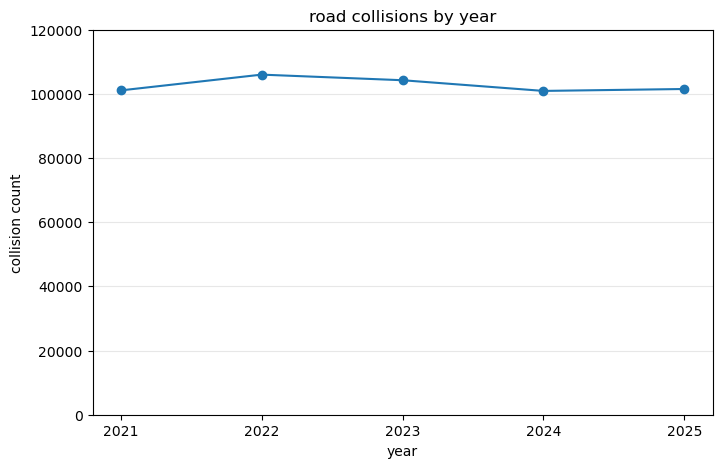

In [34]:
# total number of reported collisions changes by year
rq1_annualised["Total"].plot(kind="line", marker="o",figsize=(8, 5))

plt.title("road collisions by year")
plt.xlabel("year")
plt.ylabel("collision count")
plt.xticks(rq1_annualised.index)
plt.ylim(bottom=0,top=120000)
plt.grid(axis="y", alpha=0.3)
plt.show()

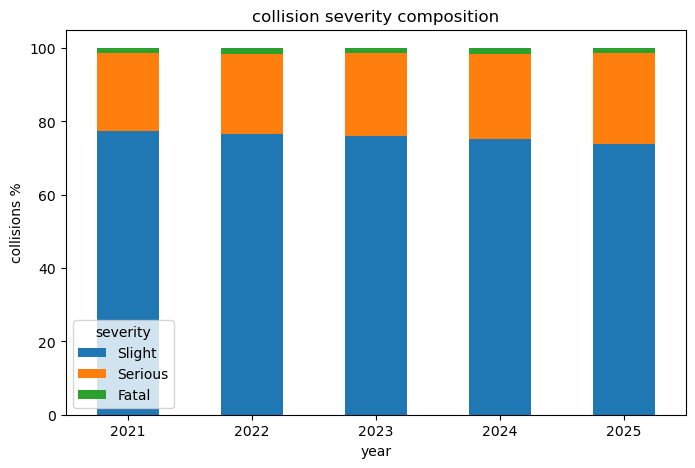

In [35]:
# check severity mix regardless of yearly totals
rq1_severity_share.plot(kind="bar",stacked=True, figsize=(8, 5))

plt.title("collision severity composition")
plt.xlabel("year")
plt.ylabel("collisions %")
plt.legend(title="severity")
plt.xticks(rotation=0)
plt.show()

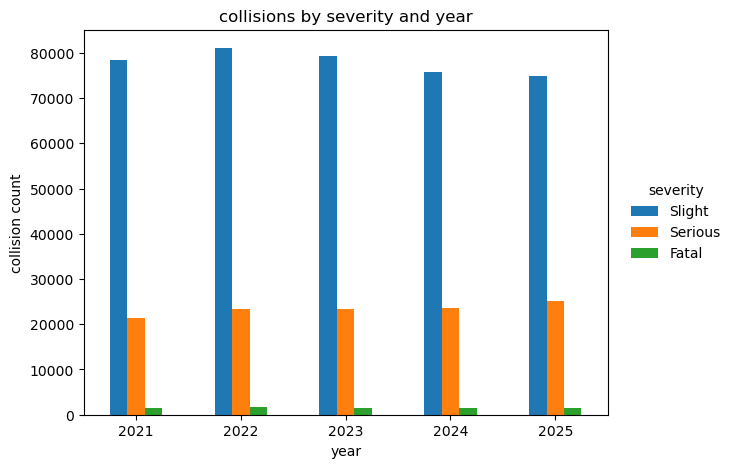

In [36]:
# compare annual counts for each severity category
ax = rq1_annualised[["Slight", "Serious", "Fatal"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("collisions by severity and year")
plt.xlabel("year")
plt.ylabel("collision count")
plt.xticks(rotation=0)

# reserve space on the right for the legend, then place it vertically outside the plot
plt.subplots_adjust(right=0.78)
ax.legend(
    title="severity",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # just outside the right edge, vertically centred
    frameon=False,
)

plt.show()

Although total reported collisions have marginally decreased over the last couple of years, the proportion of serious collisions has been steadily increasing while fatal collisions percentage remained relatively stable

### 5.3. RQ2 - How does collision severity vary across different road environments, including speed limit, road type and urban or rural location?

In [37]:
# a binary aggregated severity for comparison
roads_typed["serious_or_fatal"] = (roads_typed["severity"].isin(["Serious", "Fatal"]))

#### 3.1 Speed limit vs. Severity 

In [38]:
# calculate the serious/fatal share per speed limit
rq2_speed_aggregated = (roads_typed
    .groupby("speed_limit")
    .agg(
        collisions=("collision_index", "size"),
        serious_or_fatal_pct=("serious_or_fatal", "mean")
    )
)

rq2_speed_aggregated["serious_or_fatal_pct"] *= 100
# calculate the three severity proportions separately
rq2_speed_severity = (
    pd.crosstab(
        roads_typed["speed_limit"],
        roads_typed["severity"],
        normalize="index"
    ) * 100
)

display(rq2_speed_aggregated.round(2))
display(rq2_speed_severity.round(2))

,collisions,serious_or_fatal_pct
speed_limit,,
-1,3,33.33
20,88096,19.65
30,267325,22.65
40,44750,25.69
50,22666,28.35
60,62703,34.49
70,28258,24.62


severity,Slight,Serious,Fatal
speed_limit,,,
-1,66.67,33.33,0.00
20,80.35,19.19,0.47
30,77.35,21.78,0.87
40,74.31,23.89,1.80
50,71.65,25.46,2.89
60,65.51,30.65,3.84
70,75.38,21.25,3.37


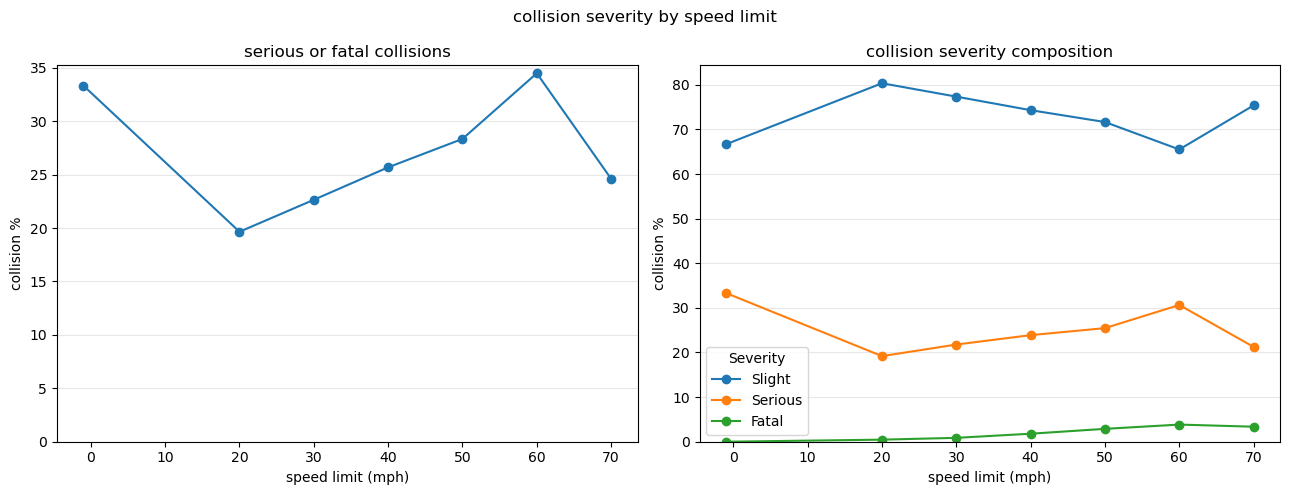

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# aggregated serious/fatal proportion
rq2_speed_aggregated["serious_or_fatal_pct"].plot(
    kind="line",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("serious or fatal collisions")
axes[0].set_xlabel("speed limit (mph)")
axes[0].set_ylabel("collision %")
axes[0].set_ylim(bottom=0)
axes[0].grid(axis="y", alpha=0.3)

# separate severity categories
rq2_speed_severity.plot(
    kind="line",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("collision severity composition")
axes[1].set_xlabel("speed limit (mph)")
axes[1].set_ylabel("collision %")
axes[1].set_ylim(bottom=0)
axes[1].legend(title="Severity")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("collision severity by speed limit")
plt.tight_layout()
plt.show()

The greatest concentration of recorded collisions is at a speed limit if 30 mph. Understandably the severity of collisions increases with increasing speed limits. One notable exception however is at roads limited to 70 mph. While fatal collision percentage remains high (3.37%) severe collision rate drops by 9.4 percentage points from 30.65% at 60mph to 21.25% at 70mph.  

One plausible explanation , this analysis does not test is - These are typically dual carriage ways and motorways which are specifically designed to reduce obstacles turns and junctions in order to facilitate faster travel. The removal of these risk factors could partly explain the lower correlation with serious and fatal collisions.

#### 3.2 Road type vs. Severity 

In [40]:
# remove road-type records that cannot be interpreted
rq2_road_type = roads_typed[roads_typed["road_type"] != "Unknown"].copy()

# compare sample size and serious/fatal share by road type
rq2_road_type_aggregated = (
    rq2_road_type
    .groupby("road_type", observed=True)
    .agg(
        collisions=("collision_index", "size"),
        serious_or_fatal_pct=("serious_or_fatal", "mean")
    )
)

rq2_road_type_aggregated["serious_or_fatal_pct"] *= 100
display(rq2_road_type_aggregated
    .sort_values("serious_or_fatal_pct", ascending=False)
    .round(2)
)

# severity proportions per road type
rq2_road_type_severity = (
    pd.crosstab(
        rq2_road_type["road_type"],
        rq2_road_type["severity"],
        normalize="index"
    ) * 100
)

display(rq2_road_type_severity.round(2))

,collisions,serious_or_fatal_pct
road_type,,
Single carriageway,373065,25.94
Dual carriageway,76119,22.89
Slip road,8829,17.94
One way street,11550,17.75
Roundabout,31178,17.21


severity,Slight,Serious,Fatal
road_type,,,
Dual carriageway,77.11,20.86,2.03
One way street,82.25,17.39,0.35
Roundabout,82.79,16.70,0.51
Single carriageway,74.06,24.41,1.53
Slip road,82.06,16.90,1.04


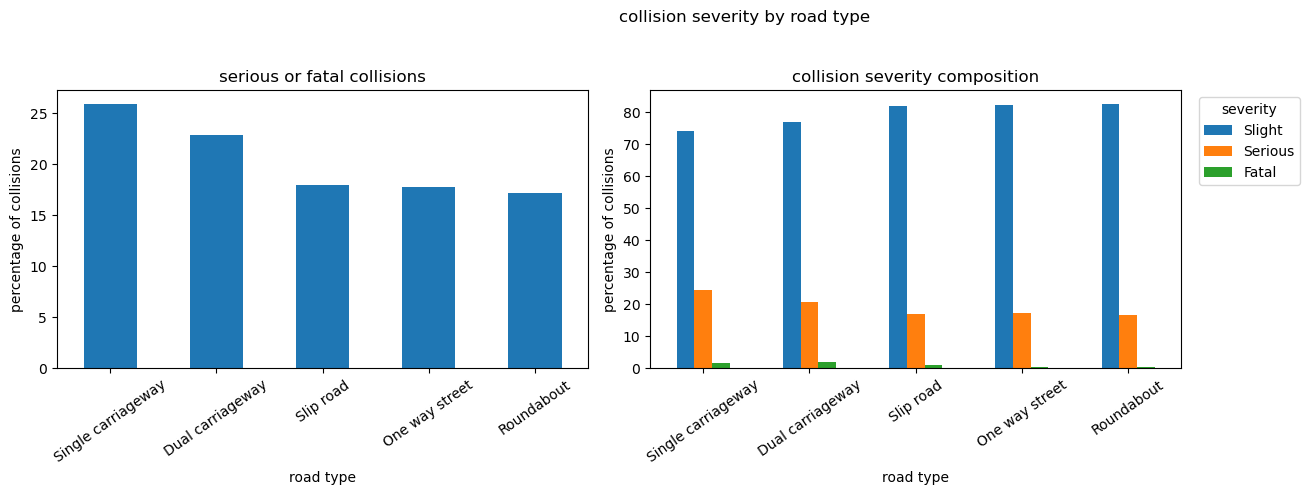

In [41]:
# same road-type order in both plots
rq2_road_order = (rq2_road_type_aggregated
    .sort_values("serious_or_fatal_pct", ascending=False)
    .index
)
rq2_road_type_aggregated = (rq2_road_type_aggregated.loc[rq2_road_order])
rq2_road_type_severity = (rq2_road_type_severity.loc[rq2_road_order])

# plot the 2 side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rq2_road_type_aggregated["serious_or_fatal_pct"].plot(kind="bar",ax=axes[0])
axes[0].set_title("serious or fatal collisions")
axes[0].set_xlabel("road type")
axes[0].set_ylabel("percentage of collisions")
axes[0].tick_params(axis="x", rotation=35)

rq2_road_type_severity.plot(kind="bar", ax=axes[1])
axes[1].set_title("collision severity composition")
axes[1].set_xlabel("road type")
axes[1].set_ylabel("percentage of collisions")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(
    title="severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.suptitle("collision severity by road type")
plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()

The majority of collisions and highest concentration of serious and fatal cases occurred on Single carriageways, which account for by far the most collisions and have the highest serious/fatal share at 25.94%. Dual carriageways are next at 22.89%, while roundabouts are lowest at 17.21%. 

#### 3.3  Urban/Rural vs. Severity 

In [42]:
# restrict this comparison to interpretable Urban and Rural records
rq2_urban_rural = roads_typed[roads_typed["urban_or_rural_area"].isin(["Urban", "Rural"])].copy()

# compare severity share between urban and rural settings
rq2_urban_rural_aggregated  = (rq2_urban_rural
    .groupby("urban_or_rural_area", observed=True)
    .agg(
        collisions=("collision_index", "size"),
        serious_or_fatal_pct=("serious_or_fatal", "mean")
    )
)

rq2_urban_rural_aggregated ["serious_or_fatal_pct"] *= 100
display(rq2_urban_rural_aggregated.round(2))

# calculate severity proportions within each area type
rq2_urban_rural_severity = (
    pd.crosstab(
        rq2_urban_rural["urban_or_rural_area"],
        rq2_urban_rural["severity"],
        normalize="index"
    ) * 100
)

display(rq2_urban_rural_severity.round(2))

,collisions,serious_or_fatal_pct
urban_or_rural_area,,
Urban,345314,21.69
Rural,168429,29.36


severity,Slight,Serious,Fatal
urban_or_rural_area,,,
Urban,78.31,20.88,0.80
Rural,70.64,26.53,2.83


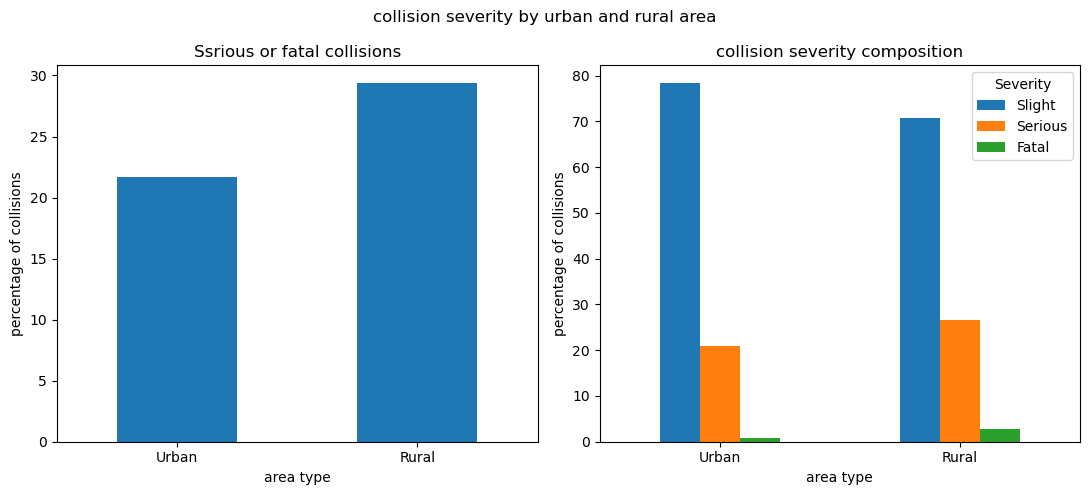

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# aggregate serious/fatal proportion
rq2_urban_rural_aggregated["serious_or_fatal_pct"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Ssrious or fatal collisions")
axes[0].set_xlabel("area type")
axes[0].set_ylabel("percentage of collisions")
axes[0].tick_params(axis="x", rotation=0)

# separate severity categories
rq2_urban_rural_severity.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("collision severity composition")
axes[1].set_xlabel("area type")
axes[1].set_ylabel("percentage of collisions")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Severity")

fig.suptitle("collision severity by urban and rural area")
plt.tight_layout()
plt.show()

Rural collisions are only 1/3 of records, but 29.36% of them were serious or fatal versus the comparatively lower proportion of 21.69% in Urban collisions. Fatal collisions specifically are 2.83% rural versus 0.80% urban — more than three times the proportion.

### 5.4. RQ3 - How does collision severity vary under different lighting, weather and road-surface conditions?
The analysis here follows a similar pattern , only the variable onf interest changes so a common function is used for filtering,transformation and exploratory plotting.

In [44]:
# variables not-used for the environmental-condition analysis - not informative for severity comparison
rq3_variables = {
    "weather_conditions": ["Unknown", "No data"],
    "light_conditions": ["No data"],
    "road_surface_conditions": ["Unknown", "No data"]
}

In [45]:
# wrapper for repetitive exploratory plotting off RQ3
def analyse_rq3(variable, excluded_values, title, x_label):
    # keep only interpretable records for this variable
    rq3_subset = roads_typed[~roads_typed[variable].isin(excluded_values)].copy()

    # aggregated serious/fatal percentage
    rq3_aggregated = (rq3_subset
        .groupby(variable, observed=True)
        .agg(
            collisions=("collision_index", "size"),
            serious_or_fatal_pct=("serious_or_fatal", "mean")
        )
    )
    rq3_aggregated["serious_or_fatal_pct"] *= 100

    # separate slight, Serious and Fatal percentages
    rq3_severity = (pd.crosstab(
            rq3_subset[variable],
            rq3_subset["severity"],
            normalize="index"
        ) * 100
    )

    display(rq3_aggregated.round(2))
    display(rq3_severity.round(2))

    # compare aggregated and separate severity measures
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    rq3_aggregated["serious_or_fatal_pct"].plot(kind="barh",ax=axes[0])

    axes[0].set_title("serious or fatal collisions")
    axes[0].set_ylabel(x_label)
    axes[0].set_xlabel("percentage of collisions")
    axes[0].tick_params(axis="x", rotation=40)

    rq3_severity.plot(kind="barh",ax=axes[1])
    axes[1].set_title("collision severity composition")
    axes[1].set_ylabel(x_label)
    axes[1].set_xlabel("percentage of collisions")
    axes[1].tick_params(axis="x", rotation=40)
    axes[1].legend(title="severity",bbox_to_anchor=(1.02, 1),loc="upper left")

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 0.88, 0.95])
    plt.show()

    return rq3_subset, rq3_aggregated, rq3_severity


#### 4.1 Weather

,collisions,serious_or_fatal_pct
weather_conditions,,
Fine no high winds,413632,24.74
Raining no high winds,55834,24.01
Snowing no high winds,1791,22.67
Fine + high winds,4472,29.74
Raining + high winds,5173,26.77
Snowing + high winds,238,19.33
Fog or mist,2128,28.05
Other,15955,19.83


severity,Slight,Serious,Fatal
weather_conditions,,,
Fine no high winds,75.26,23.22,1.52
Raining no high winds,75.99,22.61,1.40
Snowing no high winds,77.33,21.61,1.06
Fine + high winds,70.26,27.12,2.62
Raining + high winds,73.23,24.42,2.36
Snowing + high winds,80.67,19.33,0.00
Fog or mist,71.95,25.23,2.82
Other,80.17,19.08,0.75


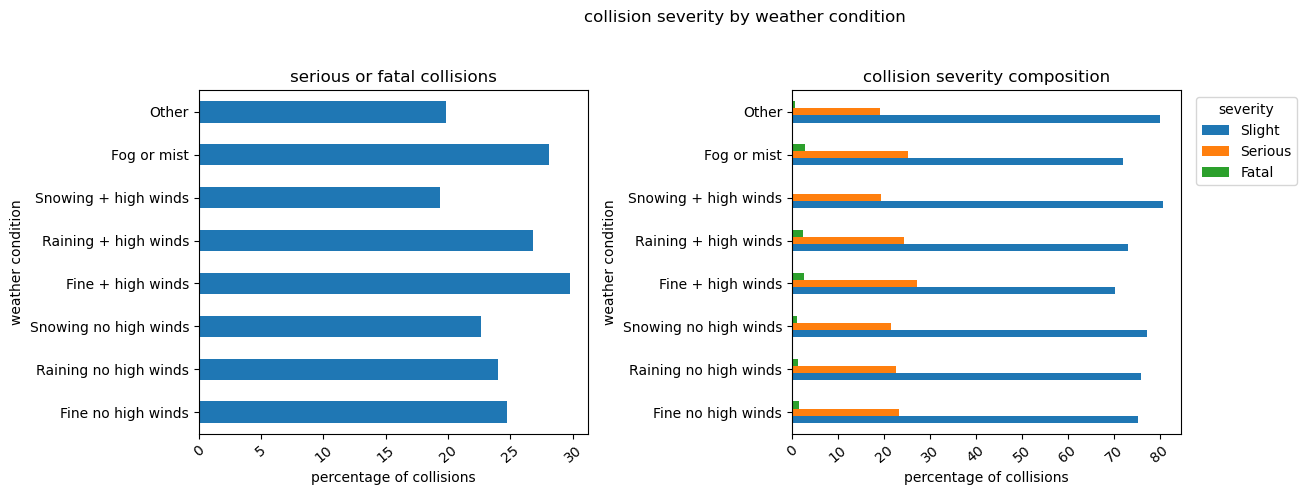

In [46]:
rq3_weather, rq3_weather_aggregated, rq3_weather_severity = analyse_rq3(
    variable="weather_conditions",
    excluded_values=["Unknown", "No data"],
    title="collision severity by weather condition",
    x_label="weather condition"
)

Fog and fine weather with high winds have the largest proportion of severe collisions at 28.05% and 29.74% respectively. Snow with high winds has the lowest collision severity at just around 20% of being serious or fatal, however it has only 238 records so it should no be interpreted strongly.

#### 4.2 Lighting

,collisions,serious_or_fatal_pct
light_conditions,,
Daylight,368193,23.19
Darkness - lights lit,105834,25.11
Darkness - lights unlit,3706,29.14
Darkness - no lighting,27438,34.95
Darkness - lighting unknown,8596,19.86


severity,Slight,Serious,Fatal
light_conditions,,,
Daylight,76.81,21.99,1.21
Darkness - lights lit,74.89,23.64,1.47
Darkness - lights unlit,70.86,26.55,2.59
Darkness - no lighting,65.05,30.13,4.81
Darkness - lighting unknown,80.14,18.26,1.59


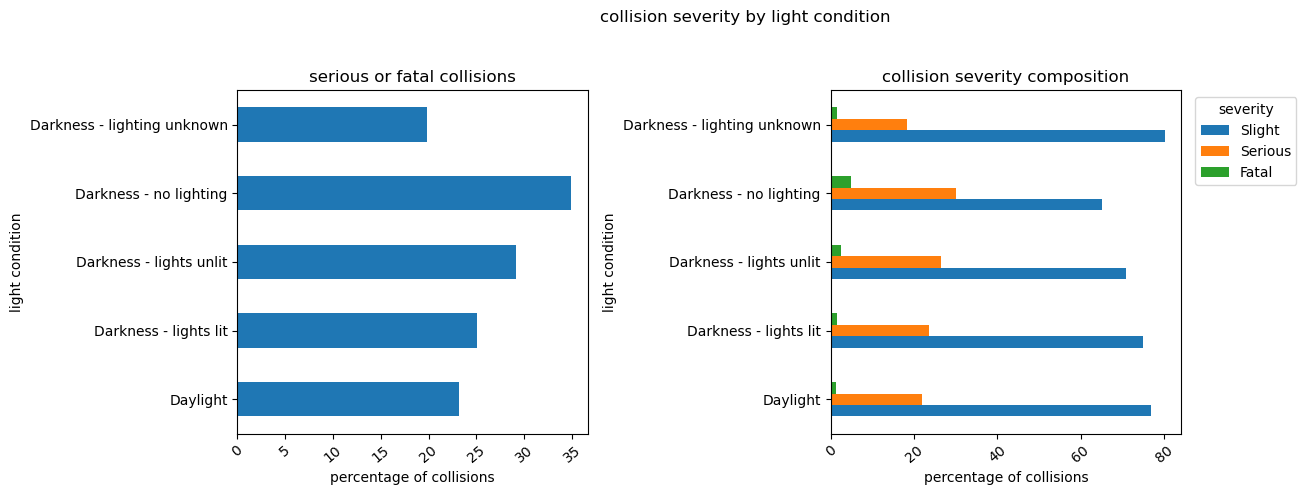

In [47]:
rq3_light, rq3_light_aggregated, rq3_light_severity = analyse_rq3(
    variable="light_conditions",
    excluded_values=["No data"],
    title="collision severity by light condition",
    x_label="light condition"
)

Serious/fatal share progresses from 23.19% in daylight to 25.11% in darkness with lights lit, 29.14% with lights unlit, and 34.95% where there is no lighting. Fatal proportion alone rises from 1.21% in daylight to 4.81% in darkness with no lighting.

#### 4.2 Road-surface

,collisions,serious_or_fatal_pct
road_surface_conditions,,
Dry,374268,24.29
Flood over 3 cm deep,788,27.28
Frost or ice,6668,22.65
Snow,1257,22.99
Wet or damp,120572,25.36


severity,Slight,Serious,Fatal
road_surface_conditions,,,
Dry,75.71,22.87,1.42
Flood over 3 cm deep,72.72,24.49,2.79
Frost or ice,77.35,21.46,1.18
Snow,77.01,21.88,1.11
Wet or damp,74.64,23.61,1.75


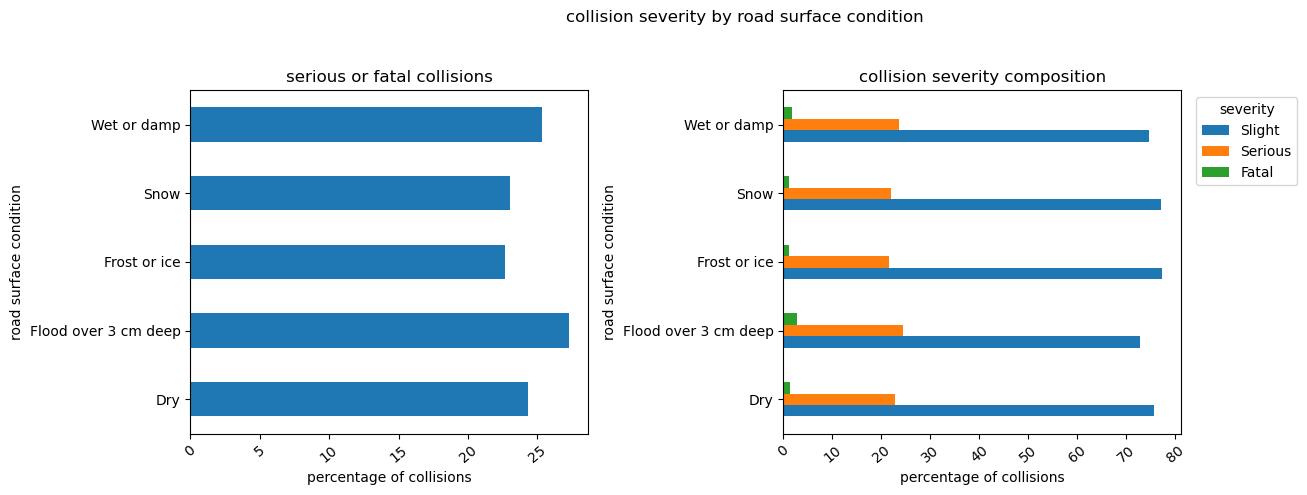

In [48]:
rq3_surface, rq3_surface_aggregated, rq3_surface_severity = analyse_rq3(
    variable="road_surface_conditions",
    excluded_values=["Unknown", "No data"],
    title="collision severity by road surface condition",
    x_label="road surface condition"
)

Wet and flood >3cm road conditions are associated with slight increase in severity rate. Although flooded collisions have higher fatality rate, they represent a small portion of the overall dataset and are more easily influenced by outliers and skew. Wet/damp is 25.36% versus is only marginally higher than dry at 24.29%. Snow and frost/ice are actually somewhat lower  


Overall lighting produces the clearest environmental severity gradient, while weather shows some differences, road-surface differences are comparatively modest.
### 5.5. RQ4 - What temporal patterns are visible in serious and fatal collisions by hour of day, day of week and month?

In [49]:
# Keep rows with valid hour and weekday values
rq4_temporal = roads_typed.dropna(subset=["hour", "day_of_week"]).copy()

#### 5.1 All collisions - Monthly/Annual patterns 

In [50]:
# compare serious/fatal collision counts across months
rq4_monthly = (rq4_temporal
    .groupby(["month_name", "severity"], observed=True)
    .size()
    .unstack(fill_value=0)
)

display(rq4_monthly)

severity,Slight,Serious,Fatal
month_name,,,
January,30740,8489,586
February,27113,7617,449
March,30741,8785,568
April,30352,9163,592
May,34129,10440,635
June,34934,10943,634
July,33826,10681,697
August,31442,10410,739
September,33969,10475,639


In [51]:
# monthly severity - accounting for different collision totals
rq4_monthly["Total"] = rq4_monthly.sum(axis=1)

rq4_monthly["serious_or_fatal_pct"] = (
    (rq4_monthly["Serious"] + rq4_monthly["Fatal"]) /
    rq4_monthly["Total"] * 100
)

display(rq4_monthly.round(2))

severity,Slight,Serious,Fatal,Total,serious_or_fatal_pct
month_name,,,,,
January,30740,8489,586,39815,22.79
February,27113,7617,449,35179,22.93
March,30741,8785,568,40094,23.33
April,30352,9163,592,40107,24.32
May,34129,10440,635,45204,24.50
June,34934,10943,634,46511,24.89
July,33826,10681,697,45204,25.17
August,31442,10410,739,42591,26.18
September,33969,10475,639,45083,24.65


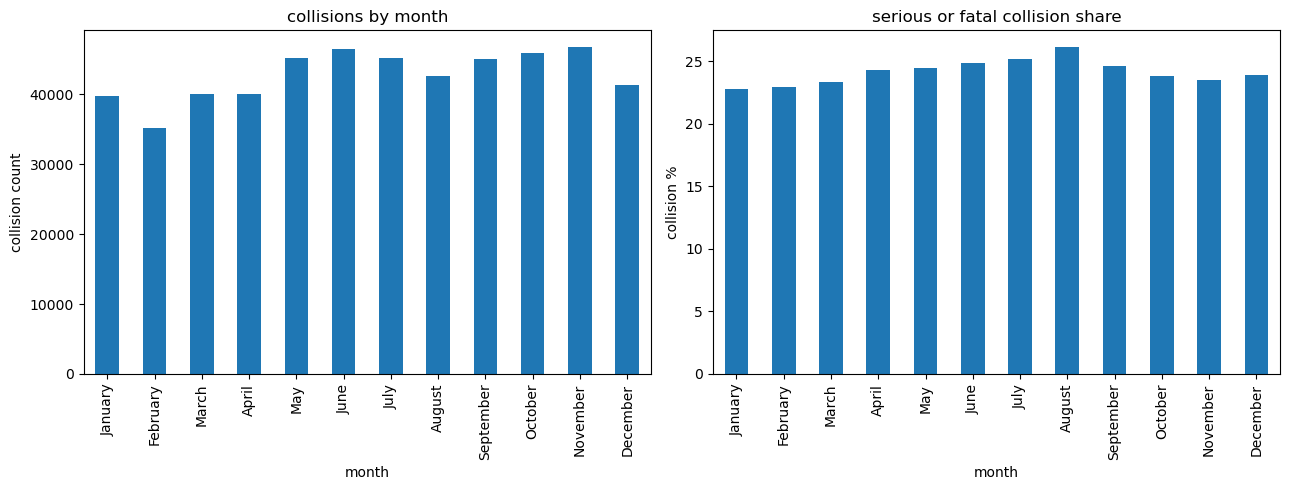

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rq4_monthly["Total"].plot(kind="bar",ax=axes[0])

axes[0].set_title("collisions by month")
axes[0].set_xlabel("month")
axes[0].set_ylabel("collision count")

rq4_monthly["serious_or_fatal_pct"].plot(kind="bar",ax=axes[1])

axes[1].set_title("serious or fatal collision share")
axes[1].set_xlabel("month")
axes[1].set_ylabel("collision %")

plt.tight_layout()
plt.show()

Total collisions tend to peak in November and June, while being the lowest in February. Serious and Fatal collisions however peak as a proportion of the monthly total in August.  

#### 5.2 All collisions - Week/hour pattern 

In [53]:
# collisions by weekday and hour
rq4_all_collisions = pd.crosstab(
    rq4_temporal["day_of_week"],
    rq4_temporal["hour"]
)

display(rq4_all_collisions)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,863,584,416,355,353,663,1563,3501,5491,3409,...,4454,6168,6211,6661,4821,3616,2580,2037,1583,1094
Tuesday,668,458,347,294,306,713,1593,3945,6313,3717,...,4516,6347,6773,7281,5366,3899,2692,2232,1764,1191
Wednesday,809,469,342,322,329,670,1647,3919,6305,3662,...,4552,6671,6717,7297,5820,4019,2784,2266,1920,1369
Thursday,891,546,369,306,295,693,1682,3771,6192,3768,...,4600,6729,6832,7268,5588,4264,3028,2437,2028,1471
Friday,986,621,451,406,436,712,1521,3299,5423,3454,...,5622,7671,7413,7328,6101,4840,3541,2993,2694,2352
Saturday,1813,1393,1019,800,688,670,817,1230,1912,2618,...,4860,4637,4824,5033,4656,3984,3268,2791,2776,2524
Sunday,2080,1539,1162,941,731,677,738,948,1224,1897,...,4349,3987,4125,3924,3584,3223,2599,2146,1885,1305


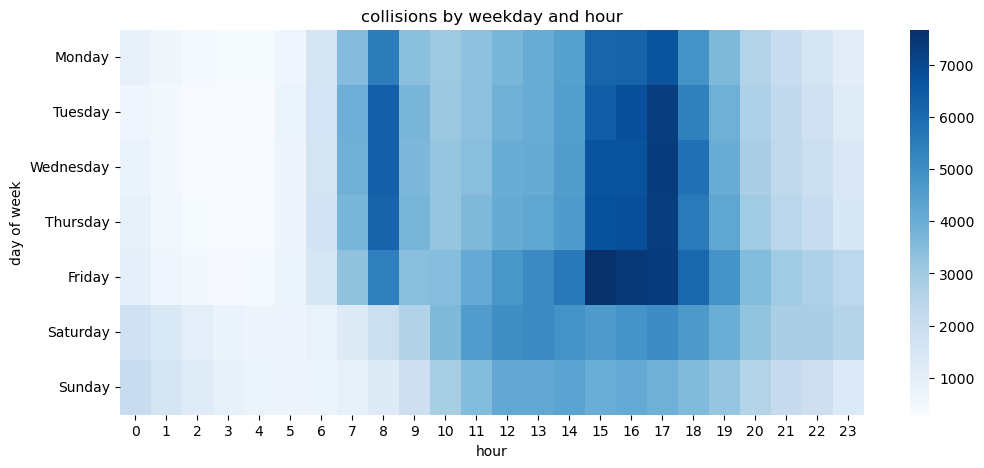

In [54]:
plt.figure(figsize=(12, 5))
sns.heatmap(rq4_all_collisions,cmap="Blues")

plt.title("collisions by weekday and hour")
plt.xlabel("hour")
plt.ylabel("day of week")
plt.show()

#### 5.3 Severe/Fatal collisions - Week/hour pattern 

In [55]:
# Focus on the temporal pattern of more severe collisions
rq4_serious_fatal = rq4_temporal[rq4_temporal["serious_or_fatal"]].copy()

rq4_serious_fatal_counts = pd.crosstab(
    rq4_serious_fatal["day_of_week"],
    rq4_serious_fatal["hour"]
)

display(rq4_serious_fatal_counts)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,250,161,134,110,133,185,428,831,1093,722,...,1056,1419,1473,1477,1128,898,637,543,471,305
Tuesday,197,133,81,96,88,194,417,870,1140,780,...,1032,1426,1532,1632,1236,888,687,592,454,348
Wednesday,238,151,100,84,98,181,410,913,1144,740,...,1046,1446,1576,1662,1349,988,711,631,560,413
Thursday,287,165,102,86,96,237,456,826,1149,773,...,1054,1548,1535,1678,1288,1049,745,639,539,428
Friday,298,187,144,134,133,191,393,761,1028,713,...,1323,1702,1690,1639,1450,1154,923,879,811,664
Saturday,577,433,320,251,199,211,199,349,498,655,...,1268,1201,1217,1279,1138,987,930,805,832,743
Sunday,661,461,386,292,217,216,222,245,325,524,...,1134,1076,1095,996,901,831,699,550,517,367


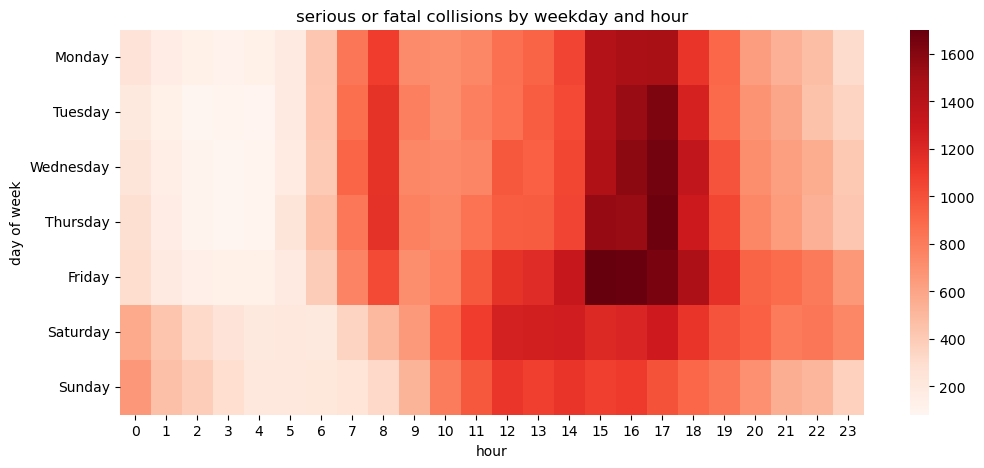

In [56]:
plt.figure(figsize=(12, 5))

sns.heatmap( rq4_serious_fatal_counts, cmap="Reds")

plt.title("serious or fatal collisions by weekday and hour")
plt.xlabel("hour")
plt.ylabel("day of week")
plt.show()

Both Total and Serious or fatal collisions are concentrated in the peak traffic hours of working weekdays. 

### 5.6. RQ5 - Where are serious and fatal collisions geographically concentrated, and how does their spatial distribution compare with reported collisions overall?

Due to the number of datapoints a scatter or map plot will likely suffer from over-saturation and obscured information , so 'binning' data into a hexbin plot was used for information clarity. 

In [57]:
# coordinates for the spatial analysis - missing data is dropped 
rq5_geo = roads_typed.dropna(subset=["longitude", "latitude"]).copy()
print("rows excluded:", len(roads_typed) - len(rq5_geo))
print("rows analysed:", len(rq5_geo))

# serious/fatal collisions data subset
rq5_serious_fatal = rq5_geo[rq5_geo["serious_or_fatal"]].copy()
print("serious or fatal collisions:", len(rq5_serious_fatal))

rows excluded: 53
rows analysed: 513748
serious or fatal collisions: 124349


#### 6.1 Overall vs severe spatial density

The High population concentration in london and correlated higher collision counts make it difficult to display more nuanced contrasts in the rest of Great Britain. So I will cap the upper display limit to show more nuanced comparisons. 

In [58]:
# keep the same spatial aggregation in exploratory and refined maps
hexgrid_size = 300
hex_cap_percentile = 95

count    20698.000000
mean        24.821142
std         85.030817
min          1.000000
25%          2.000000
50%          6.000000
75%         16.000000
max       2273.000000
dtype: float64
90th percentile: 49.0
95th percentile: 101.0
99th percentile: 336.0


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


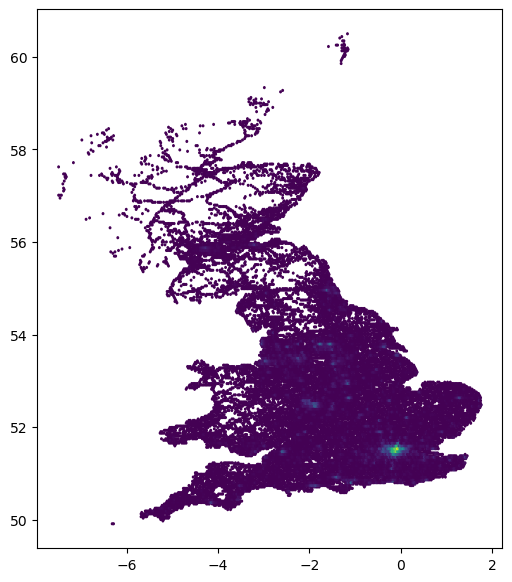

In [59]:
fig, ax = plt.subplots(figsize=(6,7))
temp_hex = ax.hexbin(
    rq5_geo["longitude"],
    rq5_geo["latitude"],
    gridsize=hexgrid_size,
    mincnt=1
)

all_hex_counts = temp_hex.get_array()
print(pd.Series(all_hex_counts).describe())

# check the count distribution to pick a sensible colour cap
print("90th percentile:", np.percentile(all_hex_counts, 90))
print("95th percentile:", np.percentile(all_hex_counts, 95))
print("99th percentile:", np.percentile(all_hex_counts, 99))

count    16667.000000
mean         7.460791
std         18.098831
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        544.000000
dtype: float64
90th percentile: 16.0
95th percentile: 29.0
99th percentile: 78.0


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


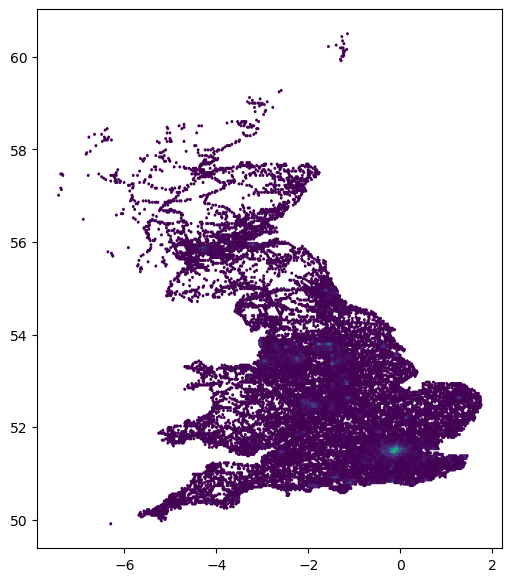

In [60]:
fig, ax = plt.subplots(figsize=(6,7))

temp_hex = ax.hexbin(
    rq5_serious_fatal["longitude"],
    rq5_serious_fatal["latitude"],
    gridsize=hexgrid_size,
    mincnt=1
)
severe_hex_counts = temp_hex.get_array()
# check the count distribution to pick a sensible colour cap
print(pd.Series(severe_hex_counts).describe())
print("90th percentile:", np.percentile(severe_hex_counts, 90))
print("95th percentile:", np.percentile(severe_hex_counts, 95))
print("99th percentile:", np.percentile(severe_hex_counts, 99))

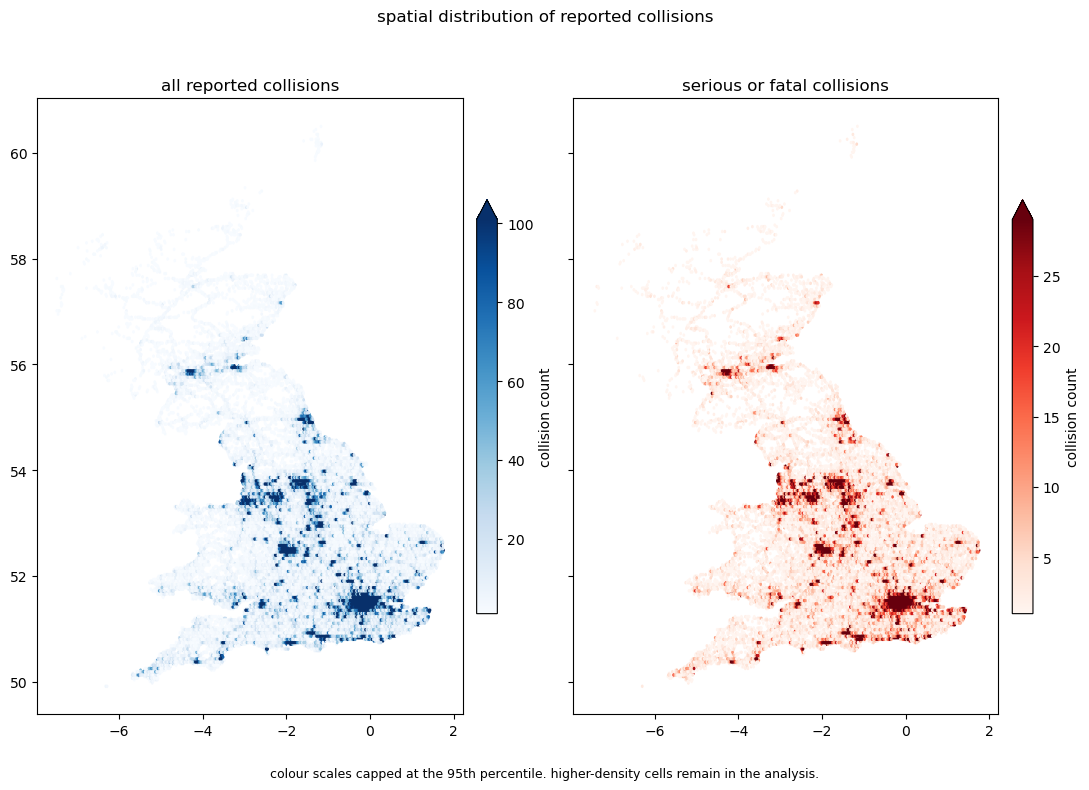

In [61]:
# defining the chosen caps 
all_cap = np.percentile(all_hex_counts, hex_cap_percentile)
severe_cap = np.percentile(severe_hex_counts, hex_cap_percentile)

fig, axes = plt.subplots(1, 2,figsize=(11, 8),sharex=True,sharey=True)

# All collisions
plot_all = axes[0].hexbin(
    rq5_geo["longitude"],
    rq5_geo["latitude"],
    gridsize=hexgrid_size,
    mincnt=1,cmap="Blues",
    vmin=1,vmax=all_cap
)
axes[0].set_title("all reported collisions")

# Serious/fatal collisions
plot_severe = axes[1].hexbin(
    rq5_serious_fatal["longitude"],
    rq5_serious_fatal["latitude"],
    gridsize=hexgrid_size,
    mincnt=1,cmap="Reds",
    vmin=1,vmax=severe_cap
)
axes[1].set_title("serious or fatal collisions")

# Shorter colourbars with visible capped scale
cbar1 = fig.colorbar(plot_all,ax=axes[0],shrink=0.70,fraction=0.045,pad=0.03,extend="max")
cbar1.set_label("collision count")

cbar2 = fig.colorbar(plot_severe,ax=axes[1],shrink=0.70,fraction=0.045,pad=0.03,extend="max")
cbar2.set_label("collision count")

fig.suptitle("spatial distribution of reported collisions")
fig.text(0.5,0.02,
    f"colour scales capped at the {hex_cap_percentile}th percentile. "
    "higher-density cells remain in the analysis.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

Both total and severe collisions are concentrated in the London Metropolitan area, while secondary concentrations can be observed in major city areas in Yorkshire and Birmingham.



#### 6.2 Serious/fatal share spatially

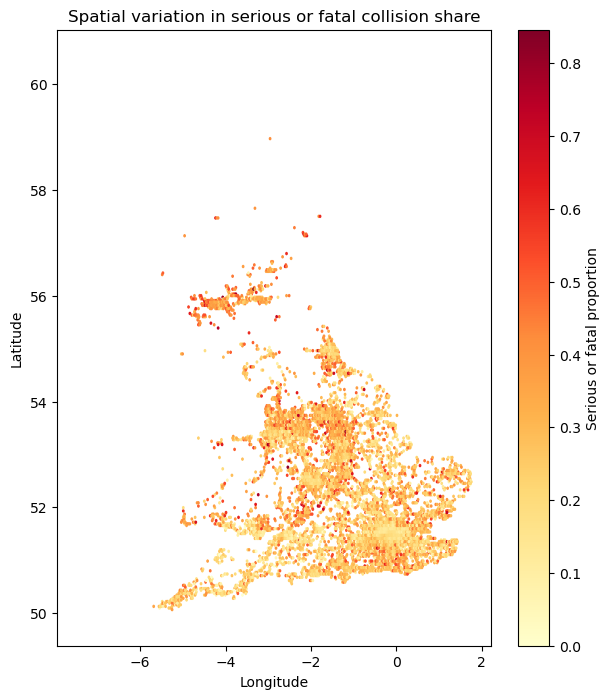

In [62]:
plt.figure(figsize=(7, 8))

# map the proportion of collisions that were serious or fatal
# mcint=10 so low observation cells do not display as high concentration severe-fatal collision hotspots
rq5_severity_map = plt.hexbin(
    rq5_geo["longitude"],
    rq5_geo["latitude"],
    C=rq5_geo["serious_or_fatal"].astype(int),
    reduce_C_function=np.mean,
    gridsize=hexgrid_size,
    mincnt=10,
    cmap="YlOrRd"
)


plt.title("Spatial variation in serious or fatal collision share")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(
    rq5_severity_map,
    label="Serious or fatal proportion"
)

plt.show()

Serious or fatal collisions form a larger proportion in The Midlands. However , these regions have been shown to have a relatively lower total collision count so the severity may be slightly exaggerated.

## 6. Explanatory Visualisation
In the Analysis section I performed an exploratory analysis to identify the main patterns relevant to the five research questions. The following visualisations were selected and refined for the final report to communicate these findings more efficiently. 

In [63]:
# severity colours must be consistent across all final visualisations
severity_colours = {
    "Slight": "#4C78A8",
    "Serious": "#F2A541",
    "Fatal": "#B23A48"
}
serious_fatal_colour = "#7008AC"

# fix severity plotting order for consistency
severity_order = ["Fatal", "Serious","Slight"]

### 6.1 RQ1 - Annual change and severity

**Key observations to show**: decline in overall collisions after the 2022 peak.Serious collisions increasing while Slight and Fatal counts decline. Fatal proportion relatively stable.

Plot choice: **compound bar + line figure with common x-axis**

* time represented consistently on both panels
* bars emphasise annual volume
* lines emphasise change in severity proportions
* minimal headings — axes and legend carry the meaning

C:\Users\Hi\AppData\Local\Temp\ipykernel_15052\1670531843.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


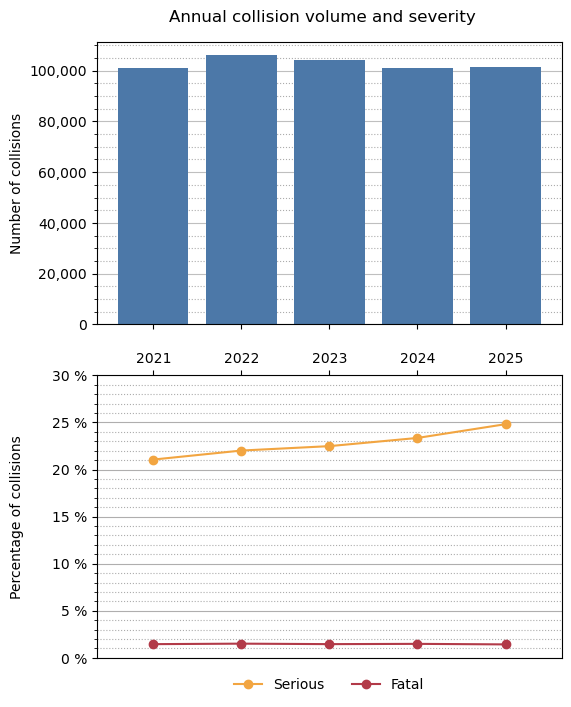

In [64]:
years = rq1_annualised.index
x = range(len(years))

fig, axes = plt.subplots(2, 1,
    figsize=(6, 8),
    sharex=True,
    gridspec_kw={"hspace": 0.18}
)

# annual collision volume
axes[0].bar(x,rq1_annualised["Total"],color="#4C78A8")
axes[0].set_ylabel("Number of collisions")
axes[0].set_ylim(bottom=0)
axes[0].grid(axis="y", alpha=0.3)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[0].minorticks_on()
axes[0].tick_params(axis='x', which='minor', bottom=False, top=False) 
axes[0].grid(axis="y", which="major", color="#B0B0B0", linestyle="-", alpha=0.8)
axes[0].grid(axis="y", which="minor", color="#5A5A5AFF", linestyle=":", alpha=0.5)
axes[0].set_axisbelow(True)

# srious and fatal proportions
axes[1].plot(x,
    rq1_annualised["Serious_pct"],
    marker="o",
    label="Serious",
    color=severity_colours["Serious"]
)
axes[1].plot(x,
    rq1_annualised["Fatal_pct"],
    marker="o",
    label="Fatal",
    color=severity_colours["Fatal"]
)
axes[1].set_ylabel("Percentage of collisions")
axes[1].set_ylim(0, 30)
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# years between the panels
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(years)
axes[1].xaxis.tick_top()

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0, symbol=' %'))
axes[1].minorticks_on()
axes[1].tick_params(axis='x', which='minor', bottom=False, top=False) 
axes[1].grid(axis="y", which="major", color="#615F5F", linestyle="-", alpha=0.5)
axes[1].grid(axis="y", which="minor", color="#5A5A5AFF", linestyle=":", alpha=0.5)

axes[1].legend(bbox_to_anchor=(0.5, -0.025),loc="upper center",ncols=2, frameon=False)
# adjust bottom layout padding so the legend isn't clipped
plt.tight_layout(rect=[0, 0, 1, 0.95])
axes[1].set_axisbelow(True)

fig.suptitle("Annual collision volume and severity", y=0.92)

fig.align_ylabels(axes)
plt.show()

### 6.2 RQ2 - Road environment and severity

**Key observations to show**: severity generally higher at higher speed limits but not at 70 mph. Single carriageways highest severe share. Rural collisions markedly higher serious/fatal proportion than Urban.

Plot choice: **vertically aligned categorical stacked bar comparison with common axis**

* all categories use same Serious and Fatal percentage measure
* stacked bar allows individual and cumulative comparisons
* common x-axis allows direct magnitude comparison
* categorical breaks separate different variable types


In [ ]:
# Speed limit
# remove unavailable speed limit information labeled "-1"
rq2_speed_limit = roads_typed[roads_typed["speed_limit"] != -1].copy()
rq2_speed_visual = (
    pd.crosstab(
        rq2_speed_limit["speed_limit"],
        rq2_speed_limit["severity"],
        normalize="index"
    ) * 100
)
rq2_speed_visual = (rq2_speed_visual[["Serious", "Fatal"]].reset_index())
# change the speed labels e.g. from "30" to "30 mph"
rq2_speed_visual["label"] = (rq2_speed_visual["speed_limit"].astype(int).astype(str) + " mph") 
rq2_speed_visual["group"] = "Speed limit"

# Road type
rq2_road_visual = (
    pd.crosstab(
        rq2_road_type["road_type"],
        rq2_road_type["severity"],
        normalize="index"
    ) * 100
)
rq2_road_visual = (rq2_road_visual[["Serious", "Fatal"]].reset_index().rename(columns={"road_type": "label"}))
rq2_road_visual["group"] = "Road type"


# Urban / rural
rq2_area_visual = (
    pd.crosstab(
        rq2_urban_rural["urban_or_rural_area"],
        rq2_urban_rural["severity"],
        normalize="index"
    ) * 100
)

rq2_area_visual = (rq2_area_visual[["Serious", "Fatal"]].reset_index().rename(columns={"urban_or_rural_area": "label"}))
rq2_area_visual["group"] = "Urban/ Rural"

rq2_visual = pd.concat(
    [
        rq2_speed_visual[["label", "group", "Serious", "Fatal"]],
        rq2_road_visual[["label", "group", "Serious", "Fatal"]],
        rq2_area_visual[["label", "group", "Serious", "Fatal"]]
    ],
    ignore_index=True
)

display(rq2_visual)

severity,label,group,Serious,Fatal
0,20 mph,Speed limit,19.188158,0.465401
1,30 mph,Speed limit,21.779482,0.869728
2,40 mph,Speed limit,23.890503,1.796648
3,50 mph,Speed limit,25.461043,2.885379
4,60 mph,Speed limit,30.650846,3.841921
5,70 mph,Speed limit,21.250619,3.365419
6,Dual carriageway,Road type,20.863385,2.029717
7,One way street,Road type,17.393939,0.354978
8,Roundabout,Road type,16.700879,0.506768
9,Single carriageway,Road type,24.410760,1.527616


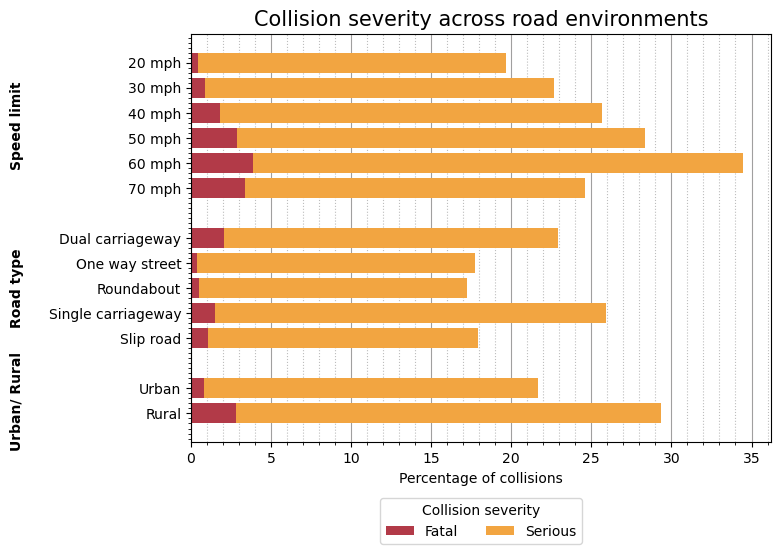

In [67]:
# define plots and subplots
fig, ax = plt.subplots(figsize=(10, 6))

y_positions = []
labels = []
serious_values = []
fatal_values = []
group_positions = {}

current_y = 0

for group in rq2_visual["group"].unique():
    group_data = rq2_visual[rq2_visual["group"] == group]
    # add space between groups
    if current_y > 0:
        current_y += 1

    group_start = current_y
    for _, row in group_data.iterrows():
        y_positions.append(current_y)
        labels.append(row["label"])
        serious_values.append(row["Serious"])
        fatal_values.append(row["Fatal"])
        current_y += 1
    group_end = current_y - 1
    group_positions[group] = (group_start + group_end) / 2


# plot the 3 stacked bar plots
# fatal first
ax.barh(
    y_positions,
    fatal_values,
    color=severity_colours["Fatal"],
    label="Fatal"
)

# serious stacked after Fatal
ax.barh(
    y_positions,
    serious_values,
    left=fatal_values,
    color=severity_colours["Serious"],
    label="Serious"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Percentage of collisions")
ax.invert_yaxis()

# add gridlines 
ax.minorticks_on()
ax.grid(axis="x",which="major",color="#615F5F",linestyle="-",alpha=0.6)
ax.grid(axis="x",which="minor",color="#5A5A5A",linestyle=":",alpha=0.4)
ax.set_axisbelow(True)

# group headings
for group, position in group_positions.items():

    ax.text(
        -0.30,
        position,
        group,
        transform=ax.get_yaxis_transform(),
        rotation=90,
        ha="center",
        va="center",
        fontweight="bold"
    )

ax.legend(title="Collision severity",loc="upper center",bbox_to_anchor=(0.5, -0.12),ncol=2)
fig.subplots_adjust(left=0.32,bottom=0.20)
plt.title("Collision severity across road environments",fontsize=15)
fig.subplots_adjust(left=0.32)
plt.show()


### 6.3 RQ3 - Environmental conditions

**Key observations to show**: strongest severity gradient in lighting conditions. Fine weather with high winds and fog/mist relatively high. Road-surface differences more modest.

Plot choice: **vertically aligned categorical comparison with common axis**

* same severity measure across all environmental conditions
* common x-axis supports direct comparison
* categorical breaks separate lighting, weather and road surface
* colour identifies environmental variable groups
* avoids three separate headings and repeated axes

In [68]:
rq3_light_plot = (
    rq3_light_aggregated
    .reset_index()
    .rename(columns={"light_conditions": "label"})
    .assign(group="Lighting")
    [["label", "group", "serious_or_fatal_pct"]]
)

rq3_weather_plot = (
    rq3_weather_aggregated
    .reset_index()
    .rename(columns={"weather_conditions": "label"})
    .assign(group="Weather")
    [["label", "group", "serious_or_fatal_pct"]]
)

rq3_surface_plot = (
    rq3_surface_aggregated
    .reset_index()
    .rename(columns={"road_surface_conditions": "label"})
    .assign(group="Road surface")
    [["label", "group", "serious_or_fatal_pct"]]
)

rq3_visual = pd.concat(
    [rq3_light_plot, rq3_weather_plot, rq3_surface_plot],
    ignore_index=True
)

display(rq3_visual)

,label,group,serious_or_fatal_pct
0,Daylight,Lighting,23.194901
1,Darkness - lights lit,Lighting,25.112913
2,Darkness - lights unlit,Lighting,29.141932
3,Darkness - no lighting,Lighting,34.947882
4,Darkness - lighting unknown,Lighting,19.858074
5,Fine no high winds,Weather,24.738173
6,Raining no high winds,Weather,24.006878
7,Snowing no high winds,Weather,22.668900
8,Fine + high winds,Weather,29.740608
9,Raining + high winds,Weather,26.773632


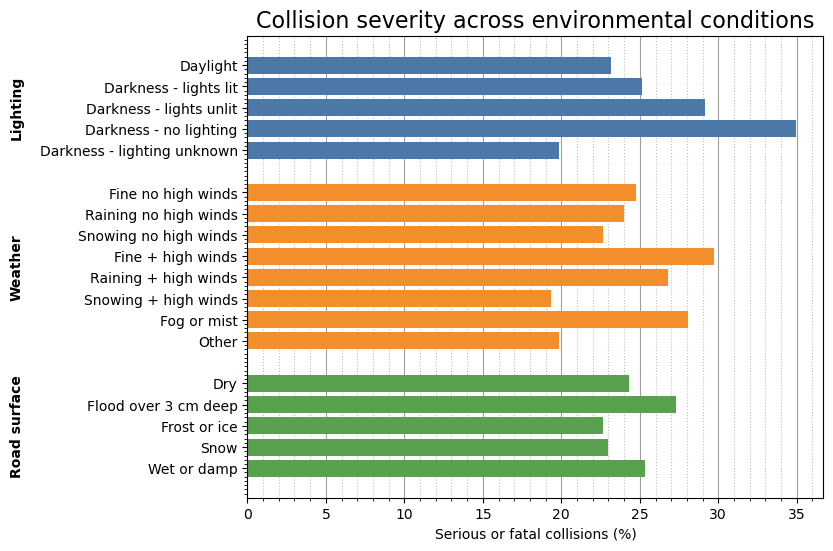

In [69]:
# add group colors for easier visual distinction between variables
rq3_group_colours = {
    "Lighting": "#4C78A8",
    "Weather": "#F28E2B",
    "Road surface": "#59A14F"
}

fig, ax = plt.subplots(figsize=(12, 6))

y_positions = []
labels = []
values = []
colours = []
group_positions = {}

current_y = 0

for group in rq3_visual["group"].unique():
    group_data = rq3_visual[rq3_visual["group"] == group]
    # add space between groups
    if current_y > 0:
        current_y += 1
    group_start = current_y

    for _, row in group_data.iterrows():
        y_positions.append(current_y)
        labels.append(row["label"])
        values.append(row["serious_or_fatal_pct"])
        colours.append(rq3_group_colours[group])
        current_y += 1

    group_end = current_y - 1
    group_positions[group] = (group_start + group_end) / 2

ax.barh(y_positions,values,color=colours)
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Serious or fatal collisions (%)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# vertical labels for each environmental variable
for group, position in group_positions.items():
    ax.text(
        -0.40,
        position,
        group,
        transform=ax.get_yaxis_transform(),
        rotation=90,
        ha="center",
        va="center",
        fontweight="bold"
    )

ax.minorticks_on()
ax.grid(axis="x", which="major", color="#615F5F", linestyle="-", alpha=0.6)
ax.grid(axis="x", which="minor", color="#5A5A5AFF", linestyle=":", alpha=0.4)
ax.set_axisbelow(True)

plt.title("Collision severity across environmental conditions", fontsize=16)
fig.subplots_adjust(left=0.42)
#plt.tight_layout()
plt.show()

### 6.4 RQ4 - Temporal patterns
**Key observations to show**: weekday collision concentration around morning/evening travel periods. 
Different late-night weekend pattern. 
Severity distribution not identical to total collision volume. 
Monthly variation comparatively modest.



#### 6.4.1 RQ4 - Weekday and hourly patterns
Plot choice: **compound heatmaps with shared axes + monthly panel**

* two ordered temporal dimensions suit matrix representation
* aggregation reduces overplotting
* same day/hour structure supports direct comparison
* count and severity share kept as separate colour scales
* shared y-axis improves visual continuity

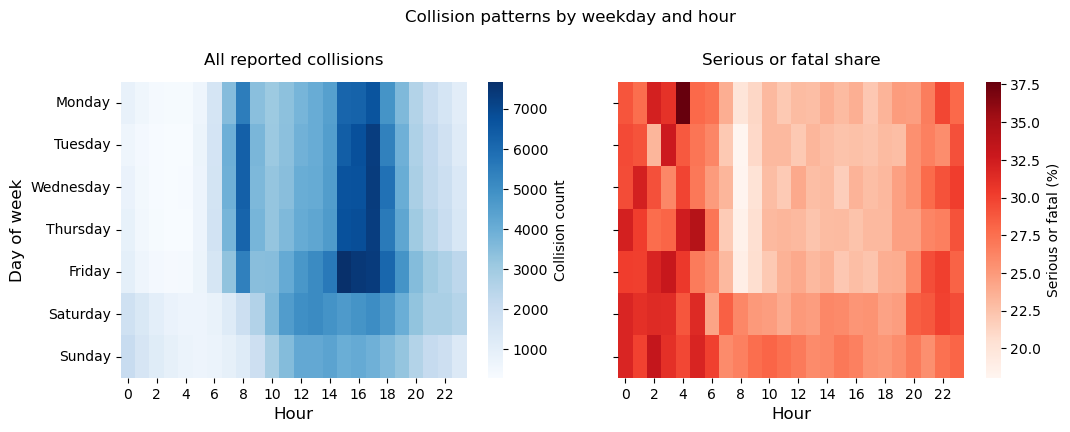

In [70]:
# set global font size for easy tweaking (this is scaled for legends and titles)
FONT_SIZE=12
rq4_severity_share = (
    rq4_temporal
    .groupby(["day_of_week", "hour"], observed=True)
    ["serious_or_fatal"]
    .mean()
    .unstack()
    * 100
)

rq4_severity_share = rq4_severity_share.reindex(
    index=rq4_all_collisions.index,
    columns=rq4_all_collisions.columns
)

fig, axes = plt.subplots(1, 2,figsize=(12, 4), sharey=True,
    gridspec_kw={"wspace": 0.15}   # more horizontal room between panels
)

sns.heatmap(
    rq4_all_collisions,
    cmap="Blues",
    ax=axes[0],
    cbar_kws={"label": "Collision count"}
)

sns.heatmap(
    rq4_severity_share,
    cmap="Reds",
    ax=axes[1],
    cbar_kws={"label": "Serious or fatal (%)"}
)

axes[0].set_title("All reported collisions", pad=12,fontsize=FONT_SIZE)
axes[0].set_xlabel("Hour",fontsize=FONT_SIZE)
axes[0].set_ylabel("Day of week",fontsize=FONT_SIZE)

axes[1].set_title("Serious or fatal share", pad=12,fontsize=FONT_SIZE)
axes[1].set_xlabel("Hour",fontsize=FONT_SIZE)
axes[1].set_ylabel("")

fig.suptitle("Collision patterns by weekday and hour", y=1.03,fontsize=FONT_SIZE)
fig.subplots_adjust(top=0.85, wspace=0.5)
plt.show()

#### 6.4.2 Monthly overview

Plot choice: **combined bar and line plot with shared month axis**
* one temporal axis for two related measures
* bars suited to monthly collision totals
* line shows change in severity proportion
* secondary axis keeps count and percentage scales separate
* more concise than two independent charts

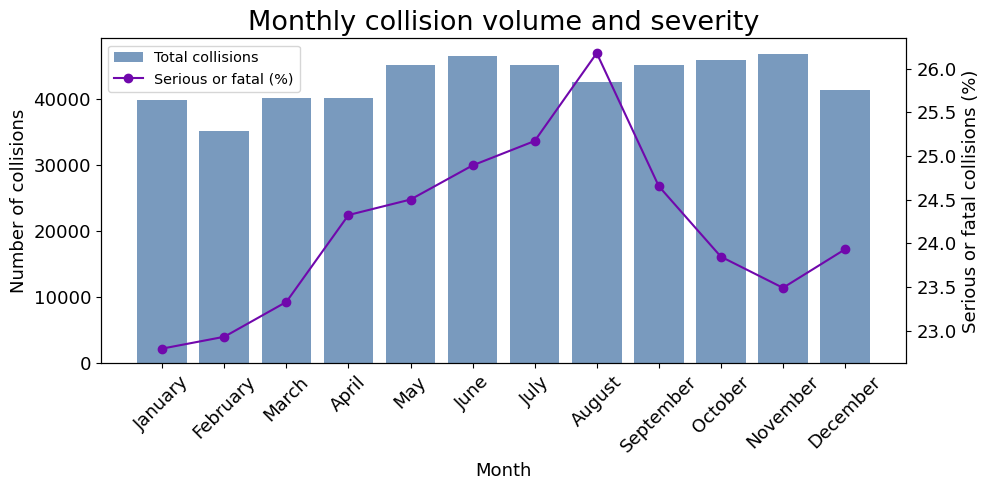

In [71]:
# set global font size for easy tweaking (this is scaled for legends and titles)
FONT_SIZE=13

fig, ax1 = plt.subplots(figsize=(10, 5))
months = rq4_monthly.index

# monthly collision volume
bars = ax1.bar(months,
    rq4_monthly["Total"],
    color="#4C78A8",
    alpha=0.75,
    label="Total collisions"
)

ax1.set_xlabel("Month",fontsize=FONT_SIZE)
ax1.set_ylabel("Number of collisions",fontsize=FONT_SIZE)
ax1.tick_params(axis="x", rotation=45, labelsize=FONT_SIZE)
ax1.tick_params(axis="y", labelsize=FONT_SIZE)

# serious/fatal percentage
ax2 = ax1.twinx()
line = ax2.plot(months,
    rq4_monthly["serious_or_fatal_pct"],
    color=serious_fatal_colour,
    marker="o",
    label="Serious or fatal (%)"
)

ax2.set_ylabel("Serious or fatal collisions (%)",fontsize=FONT_SIZE)
ax2.tick_params(axis="y", labelsize=FONT_SIZE)

# combine both legend entries
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=FONT_SIZE*0.8
)

plt.title("Monthly collision volume and severity",fontsize=FONT_SIZE*1.5)
plt.tight_layout()
plt.show()

### 6.5 RQ5 - Spatial distribution

**Key observations to show**: collisions concentrated around major populated/transport areas.
Serious/fatal collisions broadly follow overall collision geography but severity concentration is not identical.
Spatial interpretation requires geographic context - particularly country/region outlines.

Plot choice: **comparative geographic maps with common extent**
* same map extent allows direct spatial comparison
* geographic boundary provides context missing from coordinate-only plots
* aggregation reduces over-plotting from individual collision points
* comparison of maps preferred to interpreting one map in isolation
* limited road/boundary context to avoid clutter and obscuring collision pattern

In [72]:
# AI generated code 

# --- Configuration ---
GB_BOUNDARY_URL = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
    "Countries_December_2025_Boundaries_UK_BUC/FeatureServer/0/query"
    "?where=1=1&outFields=*&outSR=4326&f=geojson"
)

CACHE_PATH = Path("data/uk_countries_boundary.geojson")
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

def load_gb_boundary(url=GB_BOUNDARY_URL, cache_path=CACHE_PATH, force_refresh=False):
    """
    Load UK country boundaries as a GeoDataFrame, filtered to
    Great Britain (England, Scotland, Wales) to match STATS19 coverage.

    Downloads from the ONS Open Geography Portal on first run and
    caches locally so the notebook still runs offline/reproducibly
    afterwards. Set force_refresh=True to re-download.
    """
    if cache_path.exists() and not force_refresh:
        print(f"Loading cached boundary file: {cache_path}")
        gdf = gpd.read_file(cache_path)
    else:
        print("Downloading boundary data from ONS Open Geography Portal...")
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            cache_path.write_text(response.text, encoding="utf-8")
            gdf = gpd.read_file(cache_path)
        except (requests.RequestException, OSError) as e:
            raise RuntimeError(
                "Could not download boundary data and no local cache exists. "
                "Download manually from https://geoportal.statistics.gov.uk "
                f"(search 'Countries December 2025 Boundaries UK BUC') and place "
                f"the GeoJSON at {cache_path}. Original error: {e}"
            )

    # Restrict to Great Britain to match STATS19 scope (excludes Northern Ireland)
    gb_countries = ["England", "Scotland", "Wales"]
    name_col = "CTRY25NM" if "CTRY25NM" in gdf.columns else "CTRY_NAME"
    gdf = gdf[gdf[name_col].isin(gb_countries)].copy()

    return gdf

gb_boundary = load_gb_boundary()
print(gb_boundary[[c for c in gb_boundary.columns if "NM" in c or "NAME" in c]])
print("CRS:", gb_boundary.crs)

Loading cached boundary file: data\uk_countries_boundary.geojson
   CTRY25NM CTRY25NMW
0   England    Lloegr
2  Scotland  Yr Alban
3     Wales     Cymru
CRS: EPSG:4326


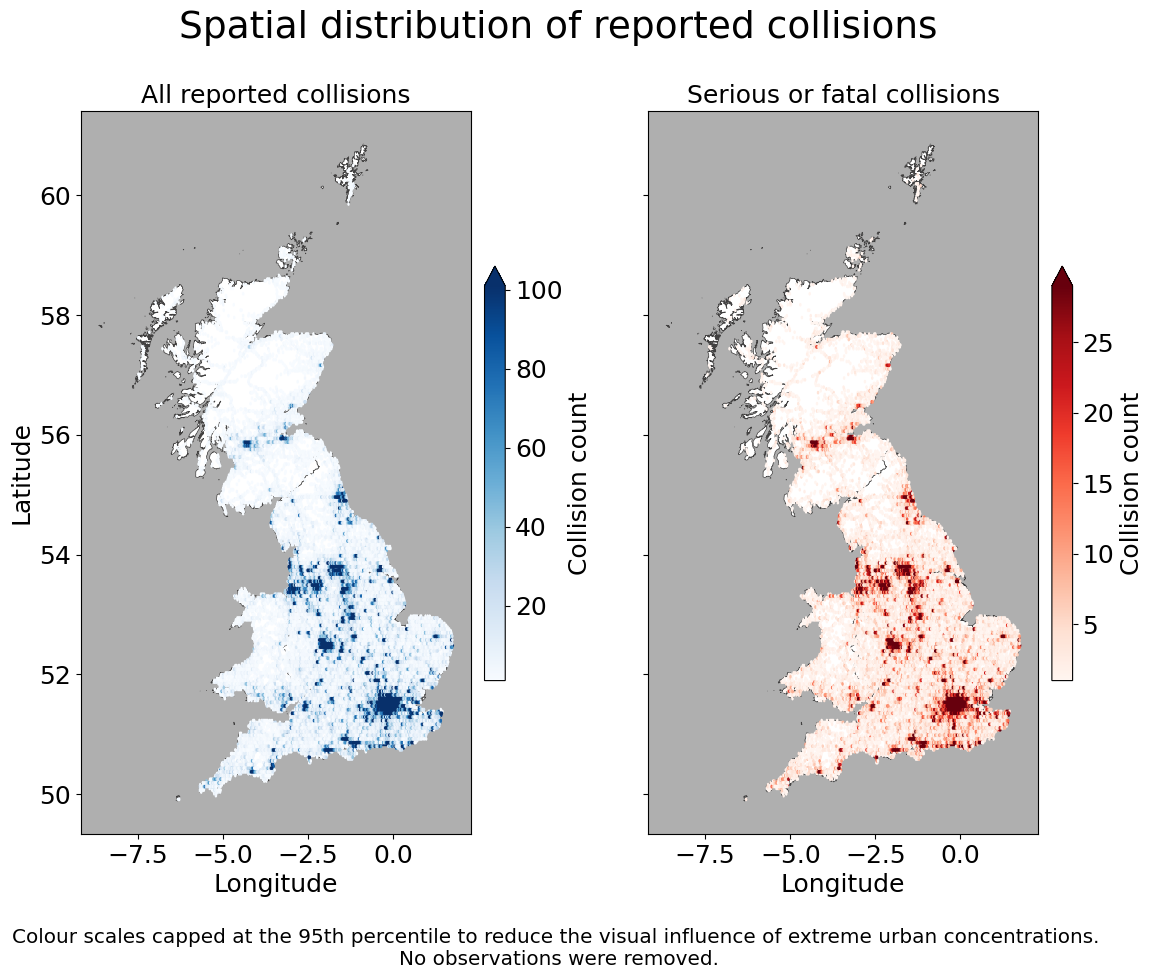

In [73]:
AXES_BG = "#AFAFAF"   # colour behind the landmass
FIG_BG = "#FFFFFF"    # for the figure margins
LAND_COLOR = "#FFFFFF"
EDGE_COLOR = "#414040"
FONT_SIZE = 18

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 10),
    sharex=True,
    sharey=True
)

fig.patch.set_facecolor(FIG_BG)  # plot area background
for ax in axes:
    ax.set_facecolor(AXES_BG)     

# base maps
gb_boundary.plot(ax=axes[0],
    facecolor=LAND_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.5
)

gb_boundary.plot(ax=axes[1],
    facecolor=LAND_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.5
)

# all collisions map
plot_all = axes[0].hexbin(
    rq5_geo["longitude"],
    rq5_geo["latitude"],
    gridsize=hexgrid_size, # constant defined earlier for consistency with exploratory maps
    mincnt=1,
    cmap="Blues",
    vmin=1,
    vmax=all_cap # constant defined earlier for consistency with exploratory maps
)

axes[0].set_title("All reported collisions",fontsize=FONT_SIZE)
axes[0].set_xlabel("Longitude",fontsize=FONT_SIZE)
axes[0].set_ylabel("Latitude",fontsize=FONT_SIZE)
axes[0].tick_params(axis="both",labelsize=FONT_SIZE)

# serious/fatal collisions map
plot_severe = axes[1].hexbin(
    rq5_serious_fatal["longitude"],
    rq5_serious_fatal["latitude"],
    gridsize=hexgrid_size,
    mincnt=1,
    cmap="Reds",
    vmin=1,
    vmax=severe_cap
)

axes[1].set_title("Serious or fatal collisions",fontsize=FONT_SIZE)
axes[1].set_xlabel("Longitude",fontsize=FONT_SIZE)
axes[1].set_ylabel("")
axes[1].tick_params(axis="both",labelsize=FONT_SIZE)

# shorten colourbars
cbar1 = fig.colorbar(plot_all,ax=axes[0],
    shrink=0.62,fraction=0.045,pad=0.03,extend="max"
)

cbar1.set_label("Collision count",fontsize=FONT_SIZE)
cbar1.ax.tick_params(labelsize=FONT_SIZE)
cbar2 = fig.colorbar(plot_severe,ax=axes[1],
    shrink=0.62,fraction=0.045,pad=0.03,extend="max")

cbar2.set_label("Collision count",fontsize=FONT_SIZE)
cbar2.ax.tick_params(labelsize=FONT_SIZE)
fig.suptitle("Spatial distribution of reported collisions",fontsize=FONT_SIZE*1.5)

fig.text(0.5,0.025,
    f"Colour scales capped at the {hex_cap_percentile}th percentile "
    "to reduce the visual influence of extreme urban concentrations. \n"
    "No observations were removed.",
    ha="center",
    fontsize=FONT_SIZE*0.8
)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

## 7. Limitations

In [74]:
# make a missing table to summarise partially removed data from each RQ subset

analysis_datasets = {
    "RQ1 - Annual": roads_typed,
    "RQ2 - Speed limit": rq2_speed_limit,
    "RQ2 - Road type": rq2_road_type,
    "RQ2 - Urban/rural": rq2_urban_rural,
    "RQ3 - Weather": rq3_weather,
    "RQ3 - Lighting": rq3_light,
    "RQ3 - Road surface": rq3_surface,
    "RQ4 - Temporal": rq4_temporal,
    "RQ5 - Geographic": rq5_geo
}

missing_summary = pd.DataFrame({"Missing count": {
        name: len(roads_typed) - len(df)
        for name, df in analysis_datasets.items()
    }
})

missing_summary["Missing (%)"] = (
    missing_summary["Missing count"]
    / len(roads_typed)
    * 100
)

display(missing_summary.round(3))

,Missing count,Missing (%)
RQ1 - Annual,0,0.000
RQ2 - Speed limit,3,0.001
RQ2 - Road type,13060,2.542
RQ2 - Urban/rural,58,0.011
RQ3 - Weather,14578,2.837
RQ3 - Lighting,34,0.007
RQ3 - Road surface,10248,1.995
RQ4 - Temporal,0,0.000
RQ5 - Geographic,53,0.010


* see report


**Reported collisions only** - not a census of every road incident in Great Britain. STATS19 covers personal-injury collisions on public roads that were reported to the police and recorded through STATS19.

**No exposure denominator** analysis compares *proportions* within reported collisions, it does not measure true road-user risk. The dataset does not contain traffic volume, vehicle-km travelled, pedestrian exposure, etc. so analysis cannot deem particular conditions as “more dangerous”.

**Observational analysis only** the associations between severity and speed limit, lighting, weather etc. cannot establish causation.
* Posted speed limit is not actual travelling speed. 
*Covariance is not explored in this study*. - environmental conditions may covary with road type, traffic levels, time of day and other factors. 

**Unequal subgroup sizes** some weather/surface categories are very small. Thus rare categories e.g. snow/flood can show high or low percentages based on relatively few collisions.

Collision clusters around London and major cities reflect where more people and traffic are present. This is why density maps show collision concentration, **not geographic risk**. The study does not employ population or traffic-flow normalization.

**Coded missing / unknown values excluded** from some parts of the analysis. Generally these are only a small part of the dataset and were only excluded from the specifically relevant question where the lack of interpretability would have caused problems - see summary table below

| Analysis subset|  Missing / excluded |% of total | Concise reason|
| --- | --- | --- | --- |
| RQ1 – Annual| 0 |0.000% | No exclusion|
| RQ2 – Speed limit  |3 |0.001% | Valid speed-limit groups only used in final visual |
| RQ2 – Road type|13,060 |2.542% | `Unknown` road type excluded|
| RQ2 – Urban/rural  |58 |0.011% | `No data` and `Unallocated` excluded|
| RQ3 – Weather|14,578 |2.837% | `Unknown` and `No data` excluded|
| RQ3 – Lighting|34 |0.007% | `No data` excluded|
| RQ3 – Road surface |10,248 |1.994% | `Unknown` and `No data` excluded|
| RQ4 – Temporal| 0 | 0.000% | No exclusion |
| RQ5 – Geographic|53 |0.010% | Missing longitude or latitude|


**Future improvement:**
* add traffic-flow or vehicle-km exposure to estimate risk rather than collision composition
* incorporate local-authority boundaries for normalized regional comparisons
* include covariance across road/environment/time variables instead of one factor at a time
* display urban hotspots at finer resolution


## 8. Conclusions

- see report

## References

- see report

## Appendices

## Word Count

The following code will count the number of words in Markdown cells. Code cells are not included.

- `Main word count` is the number of words in the main body of the text, *excluding* references or appendices.
- `References and appendices word count` is the number of words in any references or appendices.

Only `Main word count` relates to the assignment word limit. There is no limit to the number of words that can be included in references or appendices. Please note that appendices should only be used to provide context or supporting information. *No marks will be directly awarded for material submitted in appendices*.

Important:

- Please do not modify the word count code!
- To exclude references from your word count **you must** have a cell that starts with the text `## References`. Everything below this cell will not count towards the main word count.
- If you are submitting additional material as appendices **you must** have a cell that starts with the text `## Appendices`. Everything below this cell will not count towards the main word count. If you do not have any appendices you can delete the `## Appendices` cell.
- Code comments should only be used to explain details of the implementation, not for discussing your findings. All analysis commentary **must** be written in Markdown cells. *No marks will be awarded for analysis discussion submitted as comments in code cells*.

In [75]:
%%js

// Run this cell to update your word count.

function wordcount() {
    let wordCount = 0
    let extraCount = 0
    let mainBody = true

    let cells = Jupyter.notebook.get_cells()
    cells.forEach((cell) => {
        if (cell.cell_type == 'markdown') {
            let text = cell.get_text()
            // Stop counting as main body when get to References or Appendices.
            if (text.startsWith('## References') ||
                text.startsWith('## Appendices')) {
                mainBody = false
            }
            if (text.startsWith('## Word Count')) {
                text = ''
            }
            if (text) {
                let words = text.toLowerCase().match(/\b[a-z\d]+\b/g)
                if (words) {
                    let cellCount = words.length
                    if (mainBody) {
                        wordCount += cellCount
                    } else {
                        extraCount += cellCount
                    }
                }
            }
        }
    })
    return [wordCount, extraCount]
}

let wc = wordcount()
element.append(`Main word count: ${wc[0]} (References and appendices word count: ${wc[1]})`)
print(wc[0])

<IPython.core.display.Javascript object>